# Firing rate maps (per-trajectory, not pooled)

Computes occupancy and firing-rate maps for one neuron at a time, separately for each of the 50 trajectories.

Design notes (fixes vs. the original pipeline):
- Occupancy map and firing-rate map are built with the *same* `np.histogram2d` call signature (same `bins`, same fixed `range`), so they always land on an identical grid — no separate meshgrid/nearest-bin search, no row/column mismatch possible.
- Bin edges are pinned explicitly to the known trajectory bounds `[0, 1] x [0, 1]` via `range=`, instead of being derived from each call's own data min/max — every trajectory's map is on the exact same physical grid, so maps are directly comparable across trials.
- No `rotate()` calls anywhere. The only reorientation is a single `.T` + `origin='lower'` applied consistently at plot time (see `plot_random_trajectory_maps`), so there's nothing that can drift out of sync between maps.
- Activation values are converted to amplitude (`np.abs`) before binning, so complex-valued activity from the oscillatory network is handled explicitly rather than silently truncated by an implicit complex-to-real cast.
- Firing rate = occupancy-weighted mean amplitude per bin (a spatial average), not a threshold-then-peak value — avoids an arbitrary spike threshold and matches how rate maps are usually computed for continuous-valued unit activity.

In [25]:
# Trajectory grid bounds and map resolution.
# 1000 points per trajectory / 32x32 bins ~= 1 raw sample per bin before smoothing —
# fine enough to resolve field structure without every bin being empty.
BOUNDS = (0.0, 1.0)
N_BINS = 48
SIGMA = 1.0     # Gaussian smoothing bandwidth, in bins
EPS = 1e-10
layer_name = "d4"
N_COMBINED_TRAJ = 5
RANDOM_SEED = 42
SKIP_TIMESTEPS = 50

SI_THRESHOLD = 0.5
SPARSITY_THRESHOLD = 0.3


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.ndimage import gaussian_filter
import scipy.signal


### Input

In [11]:
def get_input_data(pkl_path, layer_name):
    """
    Loads trajectory-results.pkl.

    Returns
    -------
    ground_truth : (n_traj, T, 2)

    prediction : (n_traj, T, 2)

    positions : (n_traj, T, 2)

    activations : (n_traj, T, n_neurons)
    """

    with open(pkl_path, "rb") as f:
        data = pickle.load(f)

    ground_truth = np.asarray(data["ground_truth"])
    prediction   = np.asarray(data["prediction"])
    activations  = np.asarray(data[layer_name])

    # Keep only x,y if additional channels exist
    if ground_truth.shape[-1] > 2:
        ground_truth = ground_truth[..., :2]

    if prediction.shape[-1] > 2:
        prediction = prediction[..., :2]

    # ---------------------------------------------------------
    # Remove initial stabilization period
    # ---------------------------------------------------------

    if SKIP_TIMESTEPS > 0:

        ground_truth = ground_truth[:, SKIP_TIMESTEPS:, :]

        prediction = prediction[:, SKIP_TIMESTEPS:, :]

        activations = activations[:, SKIP_TIMESTEPS:, :]

    # Use prediction for occupancy / firing-rate maps
    positions = prediction.copy()

    return ground_truth, prediction, positions, activations

### Mapping functions

In [12]:
def occupancy_map_func(positions, bins=N_BINS, bounds=BOUNDS, sigma=SIGMA):
    '''
    positions: (T, 2) single trajectory.
    Returns a smoothed occupancy-count map, shape (bins, bins), axis 0 = x-bin, axis 1 = y-bin.
    '''
    H, xedges, yedges = np.histogram2d(
        positions[:, 0], positions[:, 1],
        bins=bins, range=[bounds, bounds]
    )
    occupancy = gaussian_filter(H, sigma=sigma, mode='constant', cval=0.0)
    return occupancy, xedges, yedges

In [13]:
def firing_rate_map_func(positions, activity, occupancy_map, bins=N_BINS, bounds=BOUNDS,
                          sigma=SIGMA, eps=EPS, min_occupancy=None):
    amplitude = np.abs(activity)

    activity_sum, _, _ = np.histogram2d(
        positions[:, 0], positions[:, 1],
        bins=bins, range=[bounds, bounds],
        weights=amplitude
    )
    activity_sum = gaussian_filter(activity_sum, sigma=sigma, mode='constant', cval=0.0)
    occupancy_map = gaussian_filter(occupancy_map, sigma=0, mode='constant', cval=0.0)  # already smoothed upstream — don't double-smooth

    rate_map = activity_sum / (occupancy_map + eps)

    if min_occupancy is not None:
        rate_map = np.where(occupancy_map < min_occupancy, np.nan, rate_map)

    return rate_map

In [14]:
def firing_rate_maps_for_neuron(positions, activations, neuron_idx, bins=N_BINS, bounds=BOUNDS, sigma=SIGMA, eps=EPS):
    '''
    positions:   (n_traj, T, 2)
    activations: (n_traj, T, n_neurons)
    Computes one occupancy map + one firing-rate map per trajectory (not pooled).
    Returns firing_maps, occupancy_maps, each shape (n_traj, bins, bins).
    '''
    n_traj = positions.shape[0]
    firing_maps = np.zeros((n_traj, bins, bins))
    occupancy_maps = np.zeros((n_traj, bins, bins))

    for t in range(n_traj):
        occ_map, _, _ = occupancy_map_func(positions[t], bins=bins, bounds=bounds, sigma=sigma)
        fr_map = firing_rate_map_func(
            positions[t], activations[t, :, neuron_idx], occ_map,
            bins=bins, bounds=bounds, sigma=sigma, eps=eps
        )
        occupancy_maps[t] = occ_map
        firing_maps[t] = fr_map

    return firing_maps, occupancy_maps

### Plotting

In [15]:
def plot_random_trajectory_maps(firing_maps, neuron_idx, n_show=6, bounds=BOUNDS, seed=None):
    '''
    Plots the firing-rate map for n_show randomly chosen trajectories, for one neuron.
    firing_maps: (n_traj, bins, bins) as returned by firing_rate_maps_for_neuron.
    '''
    rng = np.random.default_rng(seed)
    n_traj = firing_maps.shape[0]
    n_show = min(n_show, n_traj)
    chosen = rng.choice(n_traj, size=n_show, replace=False)

    ncols = min(3, n_show)
    nrows = int(np.ceil(n_show / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), squeeze=False)

    for ax, traj_idx in zip(axes.ravel(), chosen):
        # firing_maps[traj_idx] is indexed [x_bin, y_bin]; transpose + origin='lower'
        # displays x horizontal and y vertical-increasing-upward, applied identically every time.
        im = ax.imshow(
            firing_maps[traj_idx].T, origin='lower',
            extent=[bounds[0], bounds[1], bounds[0], bounds[1]],
            cmap='jet', aspect='auto'
        )
        ax.set_title(f'Trial {traj_idx}')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        fig.colorbar(im, ax=ax, shrink=0.8)

    for ax in axes.ravel()[len(chosen):]:
        ax.axis('off')

    fig.suptitle(f'Neuron {neuron_idx} — firing rate maps ({n_show} random trials)')
    plt.tight_layout()
    plt.show()

In [16]:
from matplotlib.gridspec import GridSpec

def plot_two_random_trajectories(
    ground_truth,
    prediction,
    positions,
    activations,
    neuron_idx,
    bins=N_BINS,
    bounds=BOUNDS,
    sigma=SIGMA,
    seed=None,
):

    rng = np.random.default_rng(seed)
    traj_ids = rng.choice(len(positions), 2, replace=False)

    # -------------------------------------------------------
    # Figure layout
    # -------------------------------------------------------

    fig = plt.figure(figsize=(13, 13), constrained_layout=True)

    gs = GridSpec(
        3,
        3,
        figure=fig,
        width_ratios=[1, 1, 0.05],
        height_ratios=[1, 1, 1],
    )

    axes = np.empty((3, 2), dtype=object)

    axes[0,0] = fig.add_subplot(gs[0,0])
    axes[0,1] = fig.add_subplot(gs[0,1])

    axes[1,0] = fig.add_subplot(gs[1,0])
    axes[1,1] = fig.add_subplot(gs[1,1])

    axes[2,0] = fig.add_subplot(gs[2,0])
    axes[2,1] = fig.add_subplot(gs[2,1])

    cax_occ = fig.add_subplot(gs[1,2])
    cax_fr  = fig.add_subplot(gs[2,2])

    occ_images = []
    fr_images = []

    # -------------------------------------------------------
    # Loop over two trajectories
    # -------------------------------------------------------

    for col, traj in enumerate(traj_ids):

        gt = ground_truth[traj]
        pred = prediction[traj]

        #######################################################
        # Row 1 : Trajectory
        #######################################################

        ax = axes[0, col]

        ax.plot(
            gt[:,0],
            gt[:,1],
            lw=2,
            color="tab:blue",
            label="Ground Truth",
        )

        ax.plot(
            pred[:,0],
            pred[:,1],
            "--",
            lw=2,
            color="tab:red",
            label="Prediction",
        )

        ax.scatter(
            gt[0,0],
            gt[0,1],
            s=90,
            color="limegreen",
            edgecolor="black",
            zorder=5,
            label="Start",
        )

        ax.scatter(
            gt[-1,0],
            gt[-1,1],
            s=110,
            color="black",
            marker="X",
            zorder=5,
            label="End",
        )

        ax.set_xlim(bounds)
        ax.set_ylim(bounds)

        ax.set_aspect("equal", adjustable="box")

        ax.set_xlabel("x")
        ax.set_ylabel("y")

        ax.grid(alpha=0.3)

        ax.set_title(f"Trajectory {traj}")

        if col == 0:
            ax.legend()

        #######################################################
        # Row 2 : Occupancy
        #######################################################

        occ_map, _, _ = occupancy_map_func(
            positions[traj],
            bins=bins,
            bounds=bounds,
            sigma=sigma,
        )

        ax = axes[1, col]

        occ_im = ax.imshow(
            occ_map.T,
            origin="lower",
            extent=[
                bounds[0],
                bounds[1],
                bounds[0],
                bounds[1],
            ],
            cmap="viridis",
            aspect="equal",
        )

        occ_images.append(occ_im)

        ax.set_title("Occupancy Map")

        ax.set_xlim(bounds)
        ax.set_ylim(bounds)

        ax.set_xlabel("x")
        ax.set_ylabel("y")

        ax.set_aspect("equal", adjustable="box")

        #######################################################
        # Row 3 : Firing Rate
        #######################################################

        fr_map = firing_rate_map_func(
            positions[traj],
            activations[traj,:,neuron_idx],
            occ_map,
            bins=bins,
            bounds=bounds,
            sigma=sigma,
        )

        ax = axes[2, col]

        fr_im = ax.imshow(
            fr_map.T,
            origin="lower",
            extent=[
                bounds[0],
                bounds[1],
                bounds[0],
                bounds[1],
            ],
            cmap="jet",
            aspect="equal",
        )

        fr_images.append(fr_im)

        ax.set_title(f"Neuron {neuron_idx}")

        ax.set_xlim(bounds)
        ax.set_ylim(bounds)

        ax.set_xlabel("x")
        ax.set_ylabel("y")

        ax.set_aspect("equal", adjustable="box")

    # -------------------------------------------------------
    # Shared colorbars
    # -------------------------------------------------------

    cb1 = fig.colorbar(
        occ_images[0],
        cax=cax_occ,
    )
    cb1.set_label("Occupancy")

    cb2 = fig.colorbar(
        fr_images[0],
        cax=cax_fr,
    )
    cb2.set_label("Firing Rate")

    fig.suptitle(
        f"Neuron {neuron_idx}: Random Trajectory Comparison",
        fontsize=18,
    )

    plt.show()

In [17]:
def compute_all_neuron_maps(
    positions,
    activations,
    traj_indices,
    bins=N_BINS,
    bounds=BOUNDS,
    sigma=SIGMA,
    eps=EPS,
    min_occupancy=None,   # <-- add this
):
    combined_positions = positions[traj_indices].reshape(-1, 2)
    combined_activations = activations[traj_indices].reshape(-1, activations.shape[-1])

    occ_map, _, _ = occupancy_map_func(
        combined_positions, bins=bins, bounds=bounds, sigma=sigma,
    )

    n_neurons = combined_activations.shape[-1]
    firing_maps = np.zeros((n_neurons, bins, bins))

    for neuron in range(n_neurons):
        firing_maps[neuron] = firing_rate_map_func(
            combined_positions,
            combined_activations[:, neuron],
            occ_map,
            bins=bins, bounds=bounds, sigma=sigma, eps=eps,
            min_occupancy=min_occupancy,   # <-- pass it down
        )

    return firing_maps, occ_map

In [18]:
def plot_neuron_grid(
    firing_maps,
    layer_name,
    traj_indices,
    bounds=BOUNDS,
):

    n_neurons = firing_maps.shape[0]

    nrows = 5
    ncols = 10

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(30, 16)
    )

    vmax = np.nanpercentile(firing_maps, 99)

    for neuron, ax in enumerate(axes.ravel()):

        if neuron >= n_neurons:
            ax.axis("off")
            continue

        im = ax.imshow(
            firing_maps[neuron].T,
            origin="lower",
            extent=[
                bounds[0],
                bounds[1],
                bounds[0],
                bounds[1],
            ],
            cmap="jet",
            vmin=0,
            vmax = np.nanpercentile(firing_maps, 99),
            interpolation="nearest",
        )

        ax.set_title(f"N{neuron}", fontsize=10)

        ax.set_xticks([])
        ax.set_yticks([])

        ax.set_aspect("equal")

    fig.suptitle(
        f"{len(traj_indices)} Combined Trajectories | Layer {layer_name}",
        fontsize=22,
        y=0.98,
    )

    # ---------------------------------------------------
    # Leave room on the right for the colorbar
    # ---------------------------------------------------

    fig.subplots_adjust(
        left=0.04,
        right=0.90,
        bottom=0.05,
        top=0.93,
        wspace=0.25,
        hspace=0.35,
    )

    # ---------------------------------------------------
    # Dedicated colorbar axis
    # ---------------------------------------------------

    cax = fig.add_axes([0.92, 0.18, 0.025, 0.64])

    cbar = fig.colorbar(
        im,
        cax=cax,
    )

    cbar.set_label(
        "Firing Rate",
        fontsize=14,
    )

    cbar.ax.tick_params(labelsize=11)

    plt.show()

In [19]:
def plot_combined_trajectory(
    ground_truth,
    prediction,
    traj_indices,
    bounds=BOUNDS,
):
    """
    Plot the pooled trajectories used to compute the firing-rate maps.

    Parameters
    ----------
    ground_truth : (n_traj, T, 2)
    prediction   : (n_traj, T, 2)
    traj_indices : list or array
    """

    fig, ax = plt.subplots(figsize=(8, 8))

    colors = plt.cm.tab10(np.linspace(0, 1, len(traj_indices)))

    for i, traj in enumerate(traj_indices):

        color = colors[i]

        # Ground truth
        ax.plot(
            ground_truth[traj, :, 0],
            ground_truth[traj, :, 1],
            color=color,
            lw=2,
            label=f"GT {traj}",
        )

        # Prediction
        ax.plot(
            prediction[traj, :, 0],
            prediction[traj, :, 1],
            "--",
            color=color,
            lw=2,
            label=f"Pred {traj}",
        )

        # Start
        ax.scatter(
            ground_truth[traj, 0, 0],
            ground_truth[traj, 0, 1],
            color=color,
            marker="o",
            s=60,
            edgecolor="black",
            zorder=5,
        )

        # End
        ax.scatter(
            ground_truth[traj, -1, 0],
            ground_truth[traj, -1, 1],
            color=color,
            marker="X",
            s=80,
            edgecolor="black",
            zorder=5,
        )

    ax.set_xlim(bounds)
    ax.set_ylim(bounds)

    ax.set_aspect("equal")

    ax.set_xlabel("x")
    ax.set_ylabel("y")

    ax.grid(alpha=0.3)

    ax.set_title(
        f"Ground Truth vs Prediction\n{len(traj_indices)} Combined Trajectories",
        fontsize=16,
    )

    ax.legend(
        fontsize=8,
        ncol=2,
        loc="upper right",
    )

    plt.show()

In [20]:
def plot_all_layers_for_trajectory(
    pkl_path,
    traj_indices,
):
    """
    Creates one 5x10 figure for every layer
    for a single trajectory.
    """

    layers = [
        "d1",
        "z1",
        "d2",
        "z2",
        "d3",
        "z3",
        "d4",
    ]

    for layer in layers:

        _, _, positions, activations = get_input_data(
            pkl_path,
            layer_name=layer,
        )

        firing_maps, _ = compute_all_neuron_maps(
            positions,
            activations,
            traj_indices)

        plot_neuron_grid(
            firing_maps,
            layer,
            traj_indices,
        )

In [21]:
def spatial_information(rate_map, occupancy_map):
    valid = ~np.isnan(rate_map)
    p = occupancy_map[valid] / occupancy_map[valid].sum()
    r = rate_map[valid]
    r_bar = np.sum(p * r)
    if r_bar <= 0:
        return 0.0
    ratio = r / r_bar
    info_terms = np.where(r > 0, p * ratio * np.log2(ratio, where=ratio > 0), 0.0)
    return np.sum(info_terms)


def sparsity(rate_map, occupancy_map):
    valid = ~np.isnan(rate_map)
    p = occupancy_map[valid] / occupancy_map[valid].sum()
    r = rate_map[valid]
    mean_r = np.sum(p * r)
    mean_r2 = np.sum(p * r ** 2)
    if mean_r2 == 0:
        return np.nan
    return (mean_r ** 2) / mean_r2

In [22]:
import pandas as pd

def compute_metrics_for_layer(
    pkl_path, layer_name, traj_indices,
    bins=N_BINS, bounds=BOUNDS, sigma=SIGMA, eps=EPS, min_occupancy=None,
):
    _, _, positions, activations = get_input_data(pkl_path, layer_name=layer_name)

    firing_maps, occupancy_map = compute_all_neuron_maps(
        positions, activations, traj_indices,
        bins=bins, bounds=bounds, sigma=sigma, eps=eps, min_occupancy=min_occupancy,
    )

    records = []
    for neuron in range(firing_maps.shape[0]):
        records.append({
            "layer": layer_name,
            "neuron": neuron,
            "spatial_info": spatial_information(firing_maps[neuron], occupancy_map),
            "sparsity": sparsity(firing_maps[neuron], occupancy_map),
        })
    return pd.DataFrame(records)


def compute_metrics_all_layers(
    pkl_path, traj_indices, layers=None,
    bins=N_BINS, bounds=BOUNDS, sigma=SIGMA, eps=EPS, min_occupancy=None,
):
    if layers is None:
        layers = ["d1", "z1", "d2", "z2", "d3", "z3", "d4"]

    dfs = [
        compute_metrics_for_layer(
            pkl_path, layer, traj_indices,
            bins=bins, bounds=bounds, sigma=sigma, eps=eps, min_occupancy=min_occupancy,
        )
        for layer in layers
    ]
    return pd.concat(dfs, ignore_index=True)

In [23]:
def plot_place_cells(
    firing_maps,
    metrics_df,
    layer_name,
    si_threshold=0.5,
    sparsity_threshold=0.3,
    bounds=BOUNDS,
):

    layer_metrics = metrics_df[
        metrics_df["layer"] == layer_name
    ]

    selected = layer_metrics[
        (layer_metrics["spatial_info"] > si_threshold) &
        (layer_metrics["sparsity"] < sparsity_threshold)
    ]

    neurons = selected["neuron"].values

    if len(neurons) == 0:
        print("No place cells found.")
        return

    ncols = 5
    nrows = int(np.ceil(len(neurons)/ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4*ncols,4*nrows)
    )

    axes = np.array(axes).reshape(-1)

    vmax = np.nanpercentile(firing_maps,99)

    for ax, neuron in zip(axes, neurons):

        ax.imshow(
            firing_maps[neuron].T,
            origin="lower",
            extent=[bounds[0],bounds[1],bounds[0],bounds[1]],
            cmap="jet",
            vmin=0,
            vmax=vmax,
        )

        si = selected[selected["neuron"]==neuron]["spatial_info"].values[0]
        sp = selected[selected["neuron"]==neuron]["sparsity"].values[0]

        ax.set_title(
            f"N{neuron}\nSI={si:.2f}\nS={sp:.2f}",
            fontsize=9,
        )

        ax.set_xticks([])
        ax.set_yticks([])

    for ax in axes[len(neurons):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

### Example usage

In [26]:


pkl_path = "/Users/ais/Desktop/2026_Summer/2d_hippocampal_cells/2D-traj-results-training.pkl"

ground_truth, prediction, positions, activations = get_input_data(
    pkl_path,
    layer_name=layer_name
)

print("Ground truth :", ground_truth.shape)
print("Prediction   :", prediction.shape)
print("Positions    :", positions.shape)
print("Activations  :", activations.shape)


Ground truth : (500, 450, 2)
Prediction   : (500, 450, 2)
Positions    : (500, 450, 2)
Activations  : (500, 450, 100)


In [27]:
ground_truth, prediction, positions, activations = get_input_data(
    pkl_path,
    layer_name=layer_name,
)

print(ground_truth.shape)
print(prediction.shape)
print(positions.shape)
print(activations.shape)

(500, 450, 2)
(500, 450, 2)
(500, 450, 2)
(500, 450, 100)


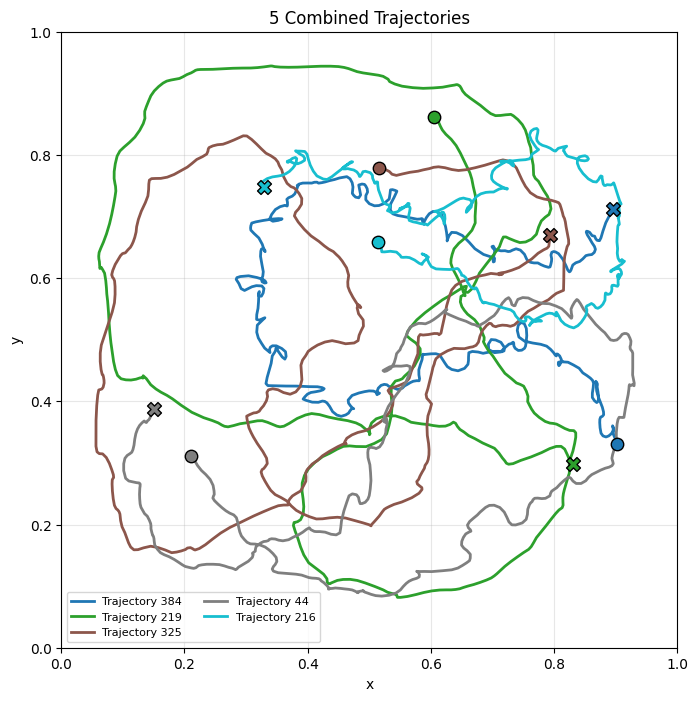

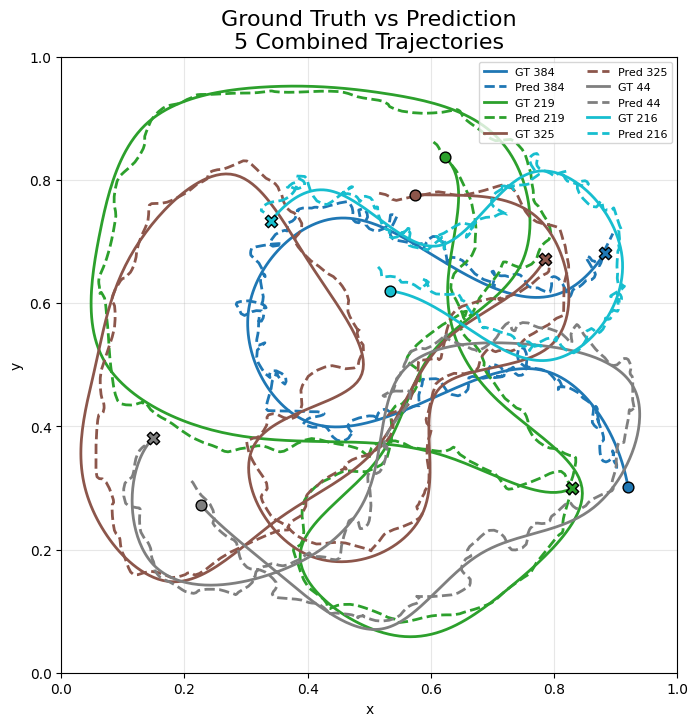

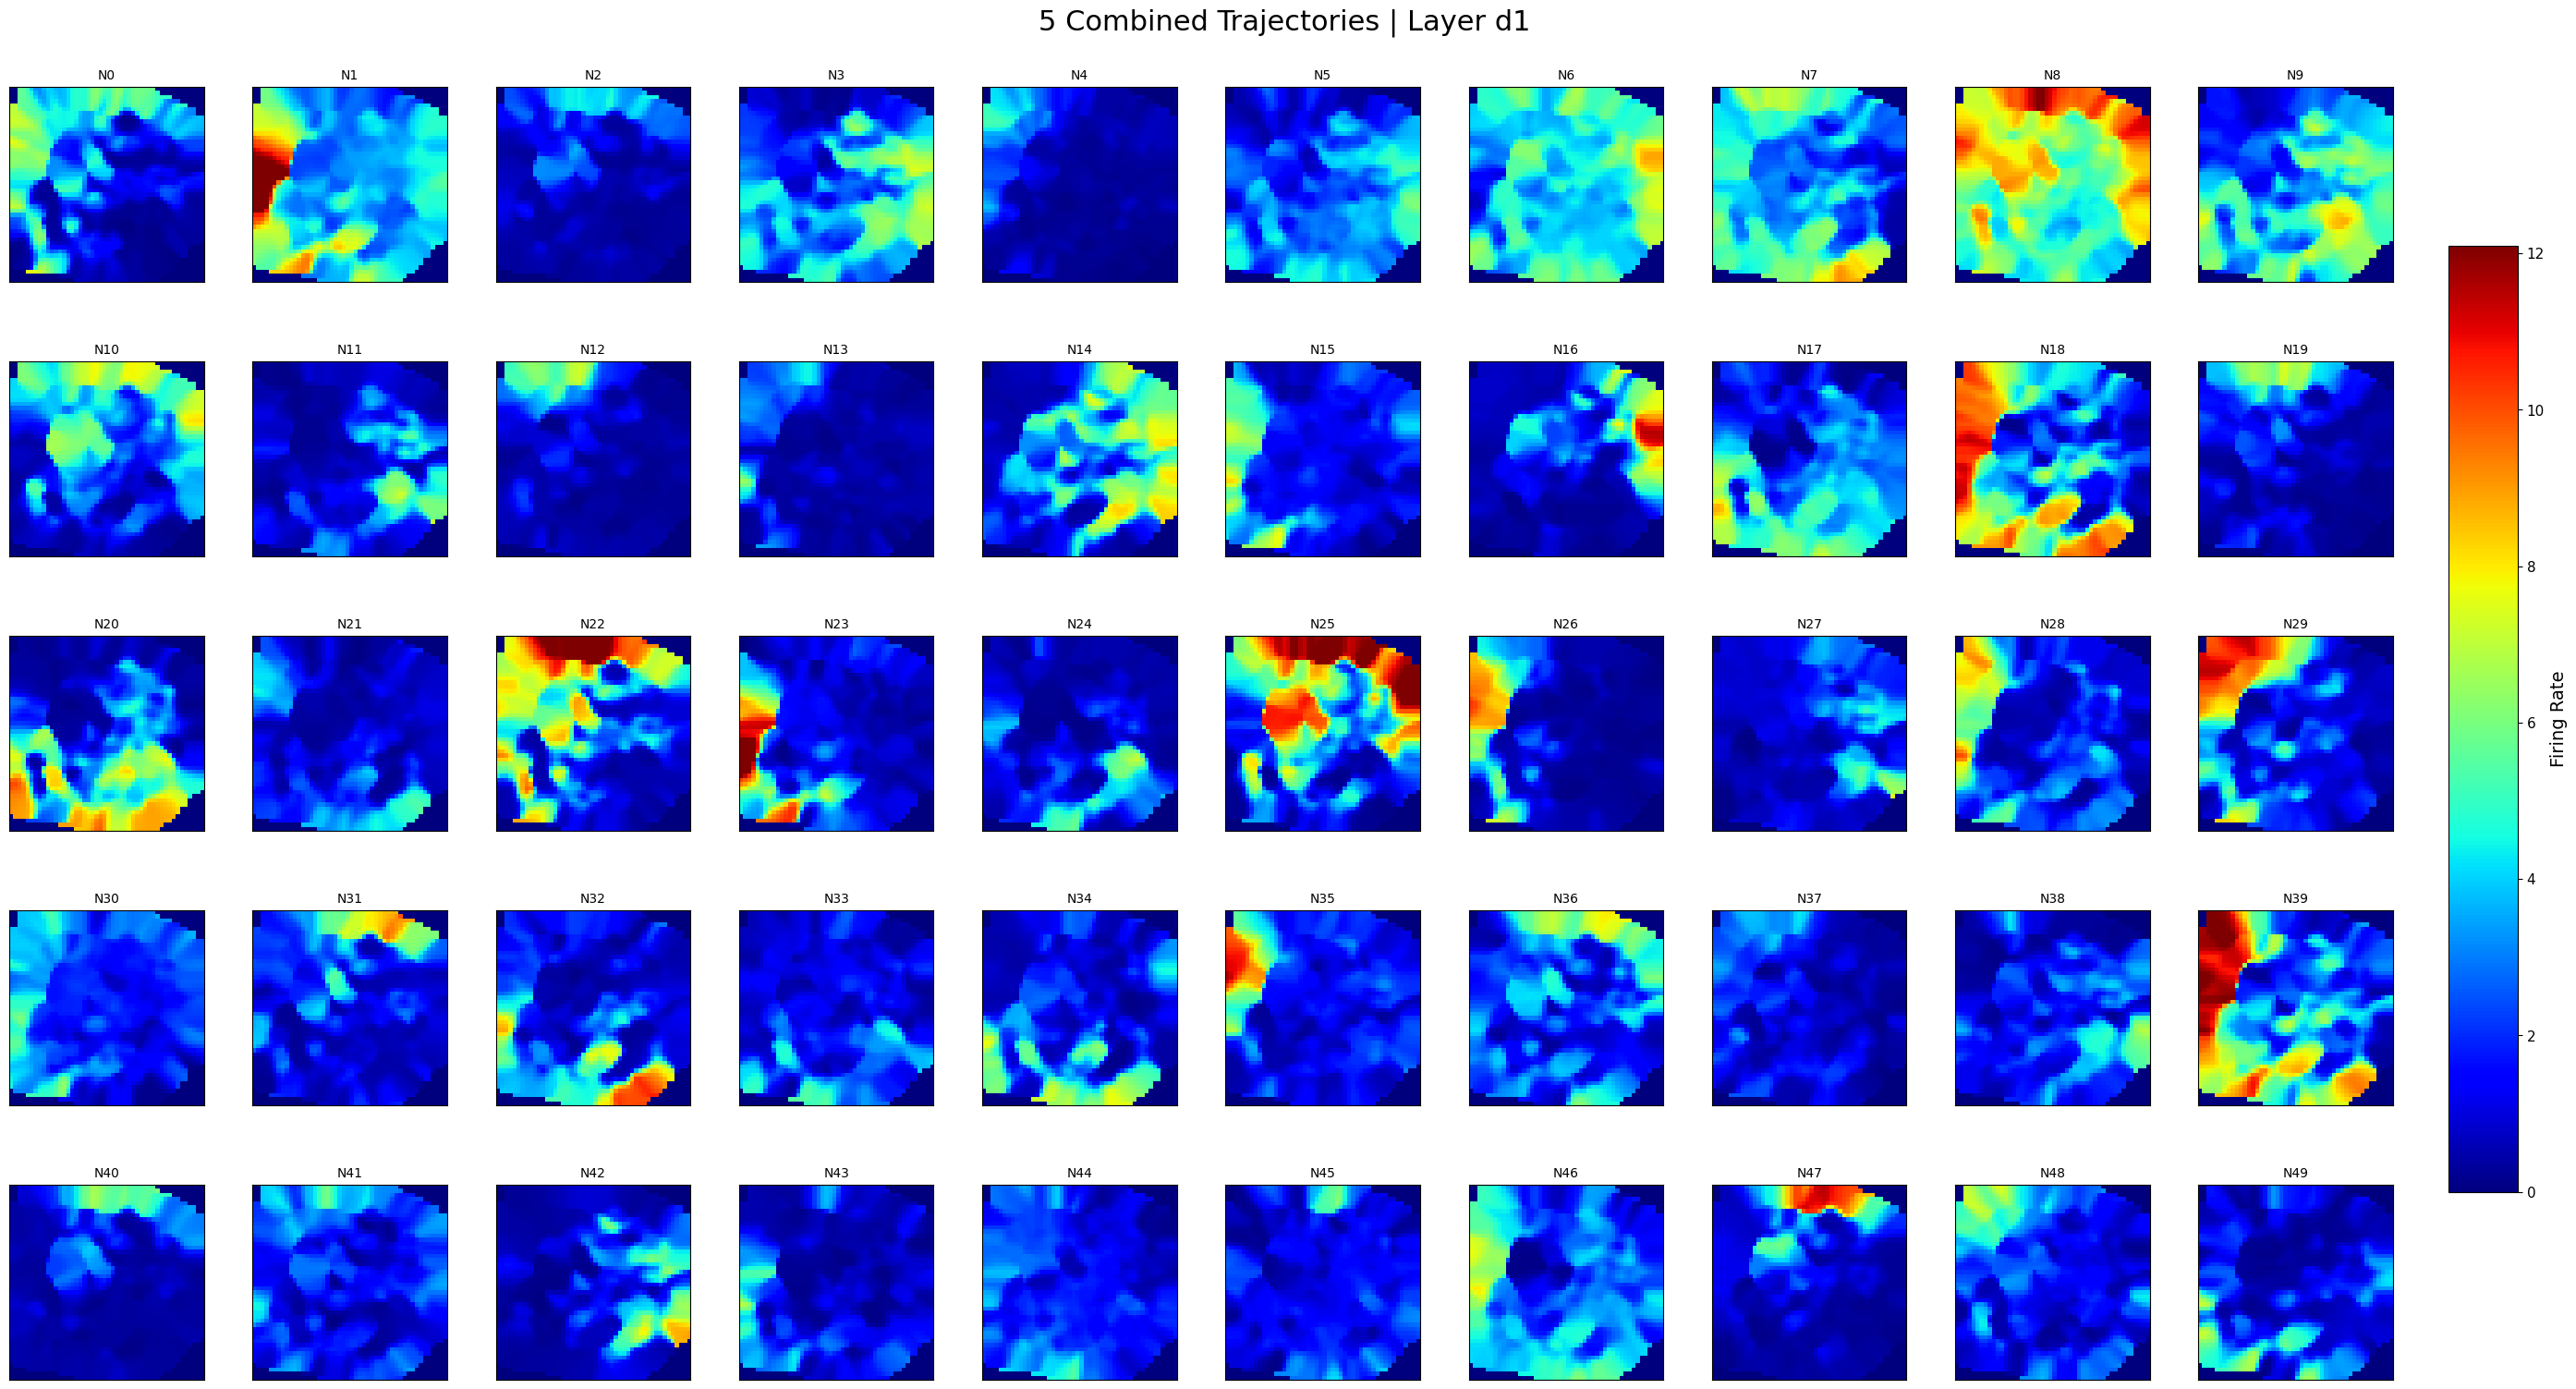

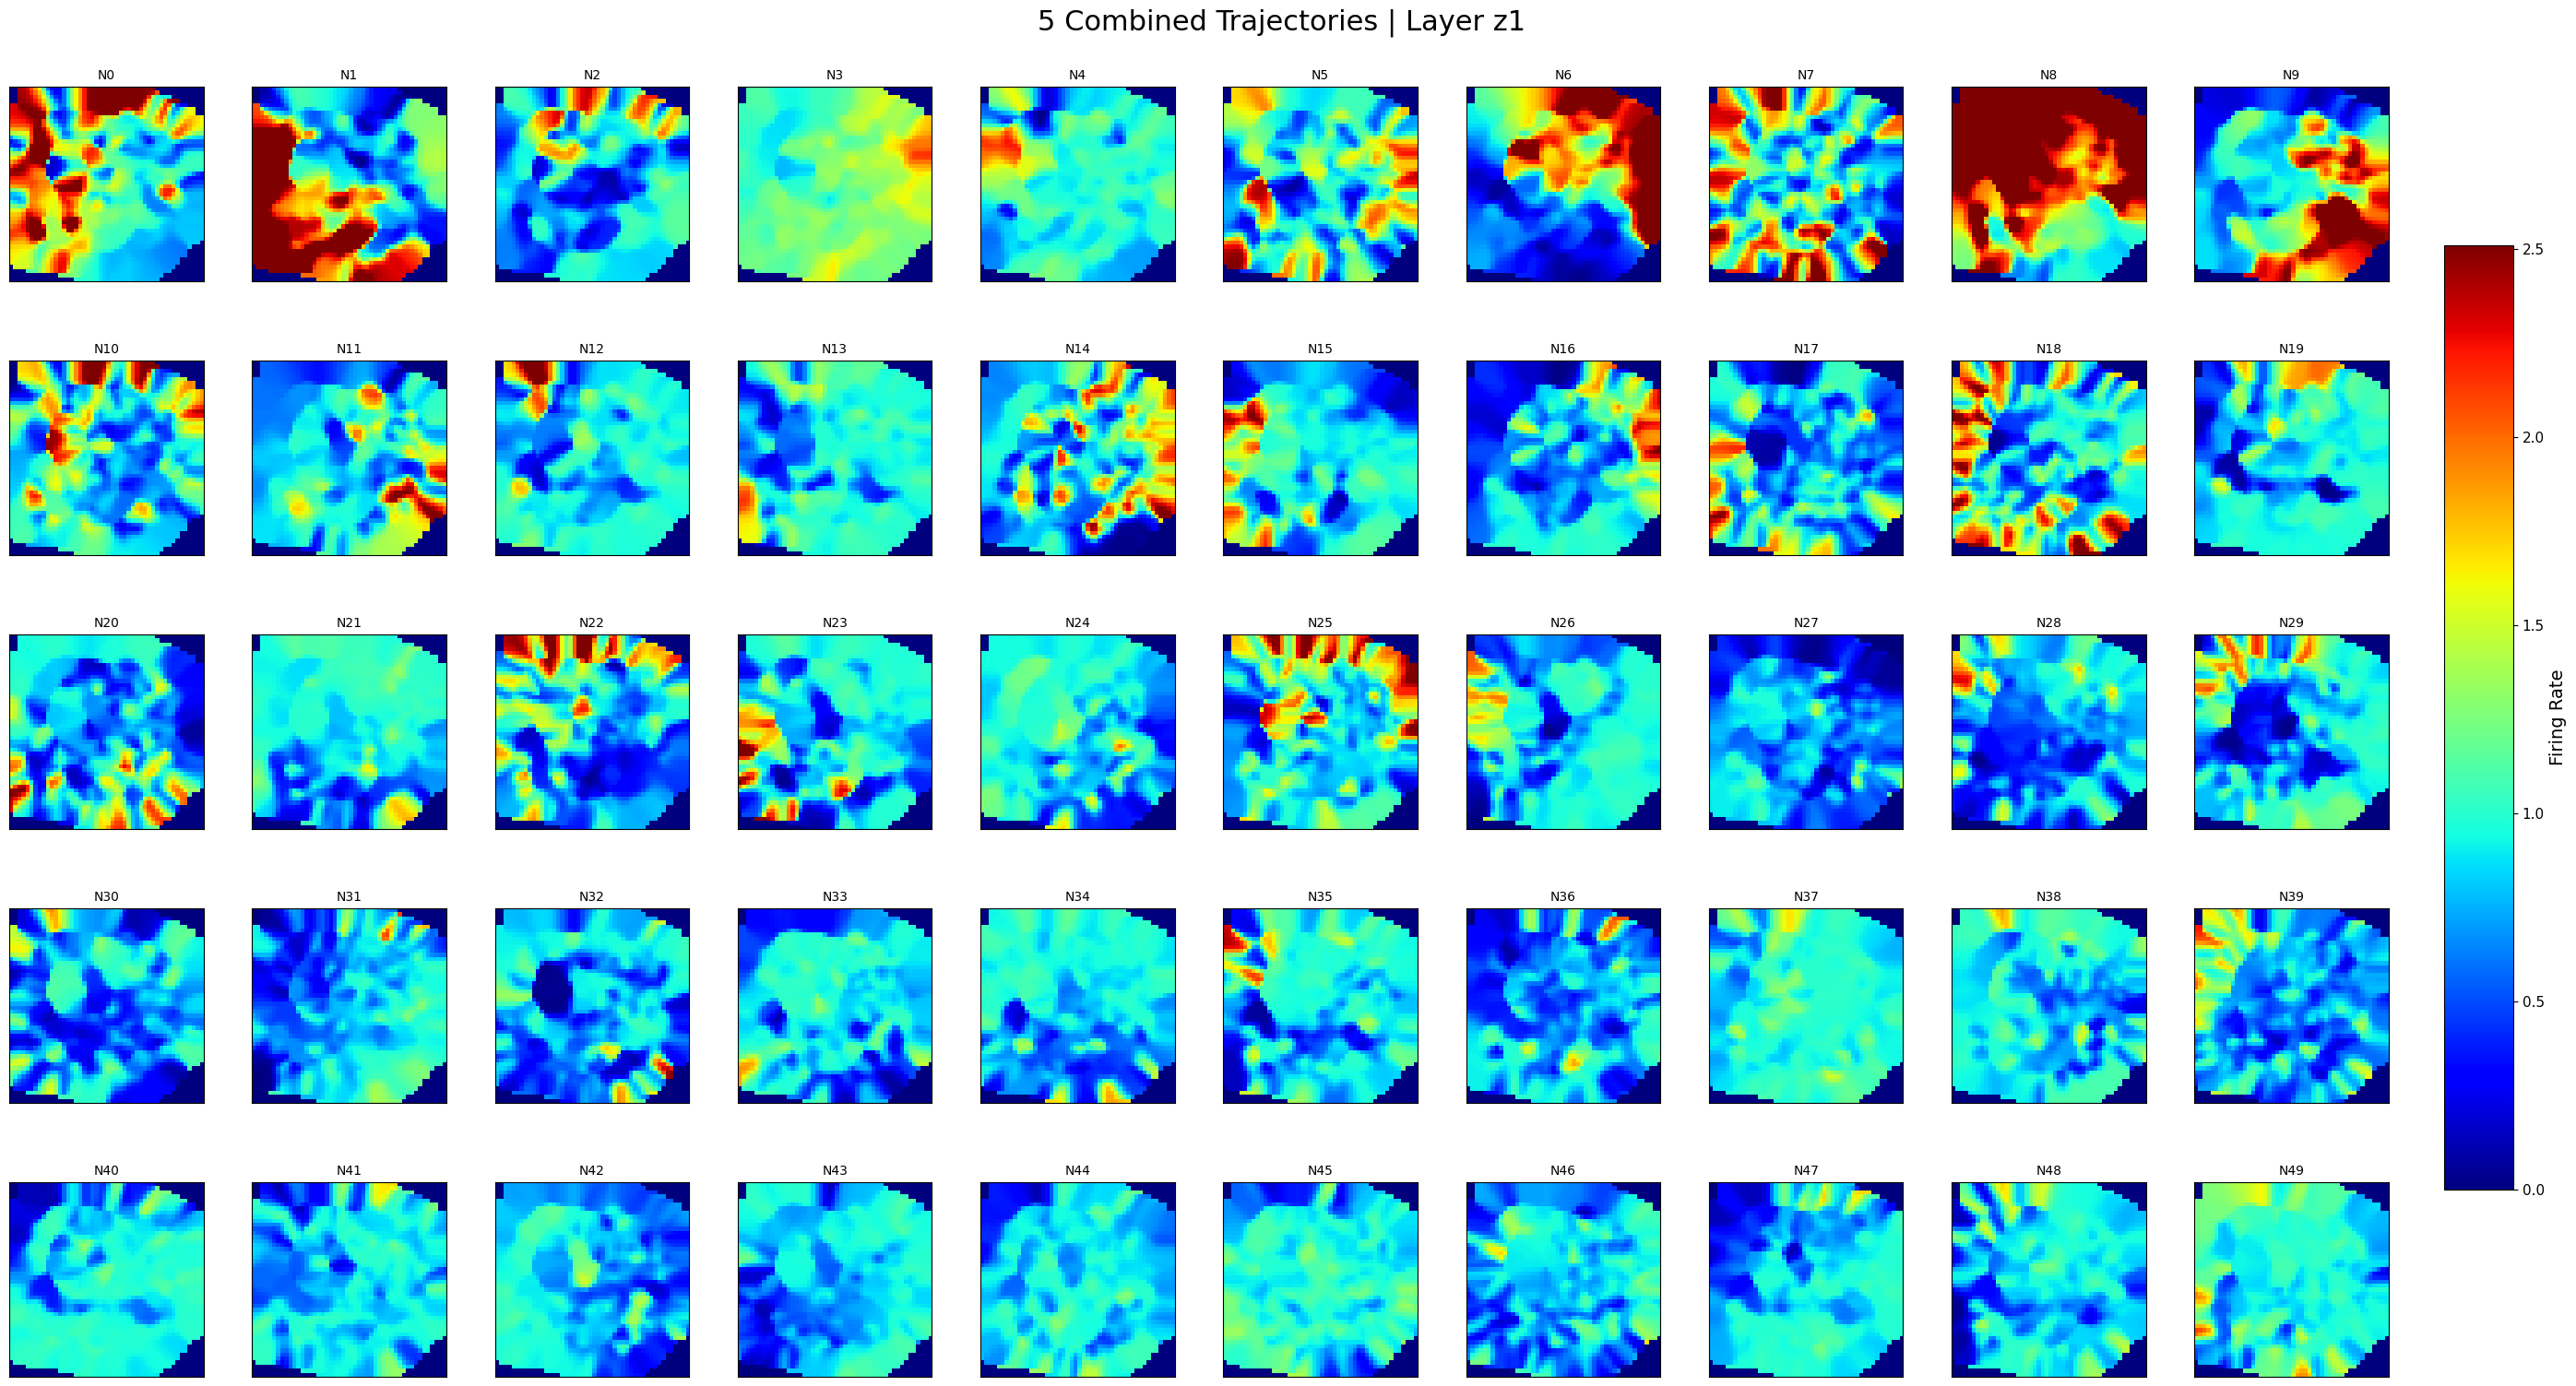

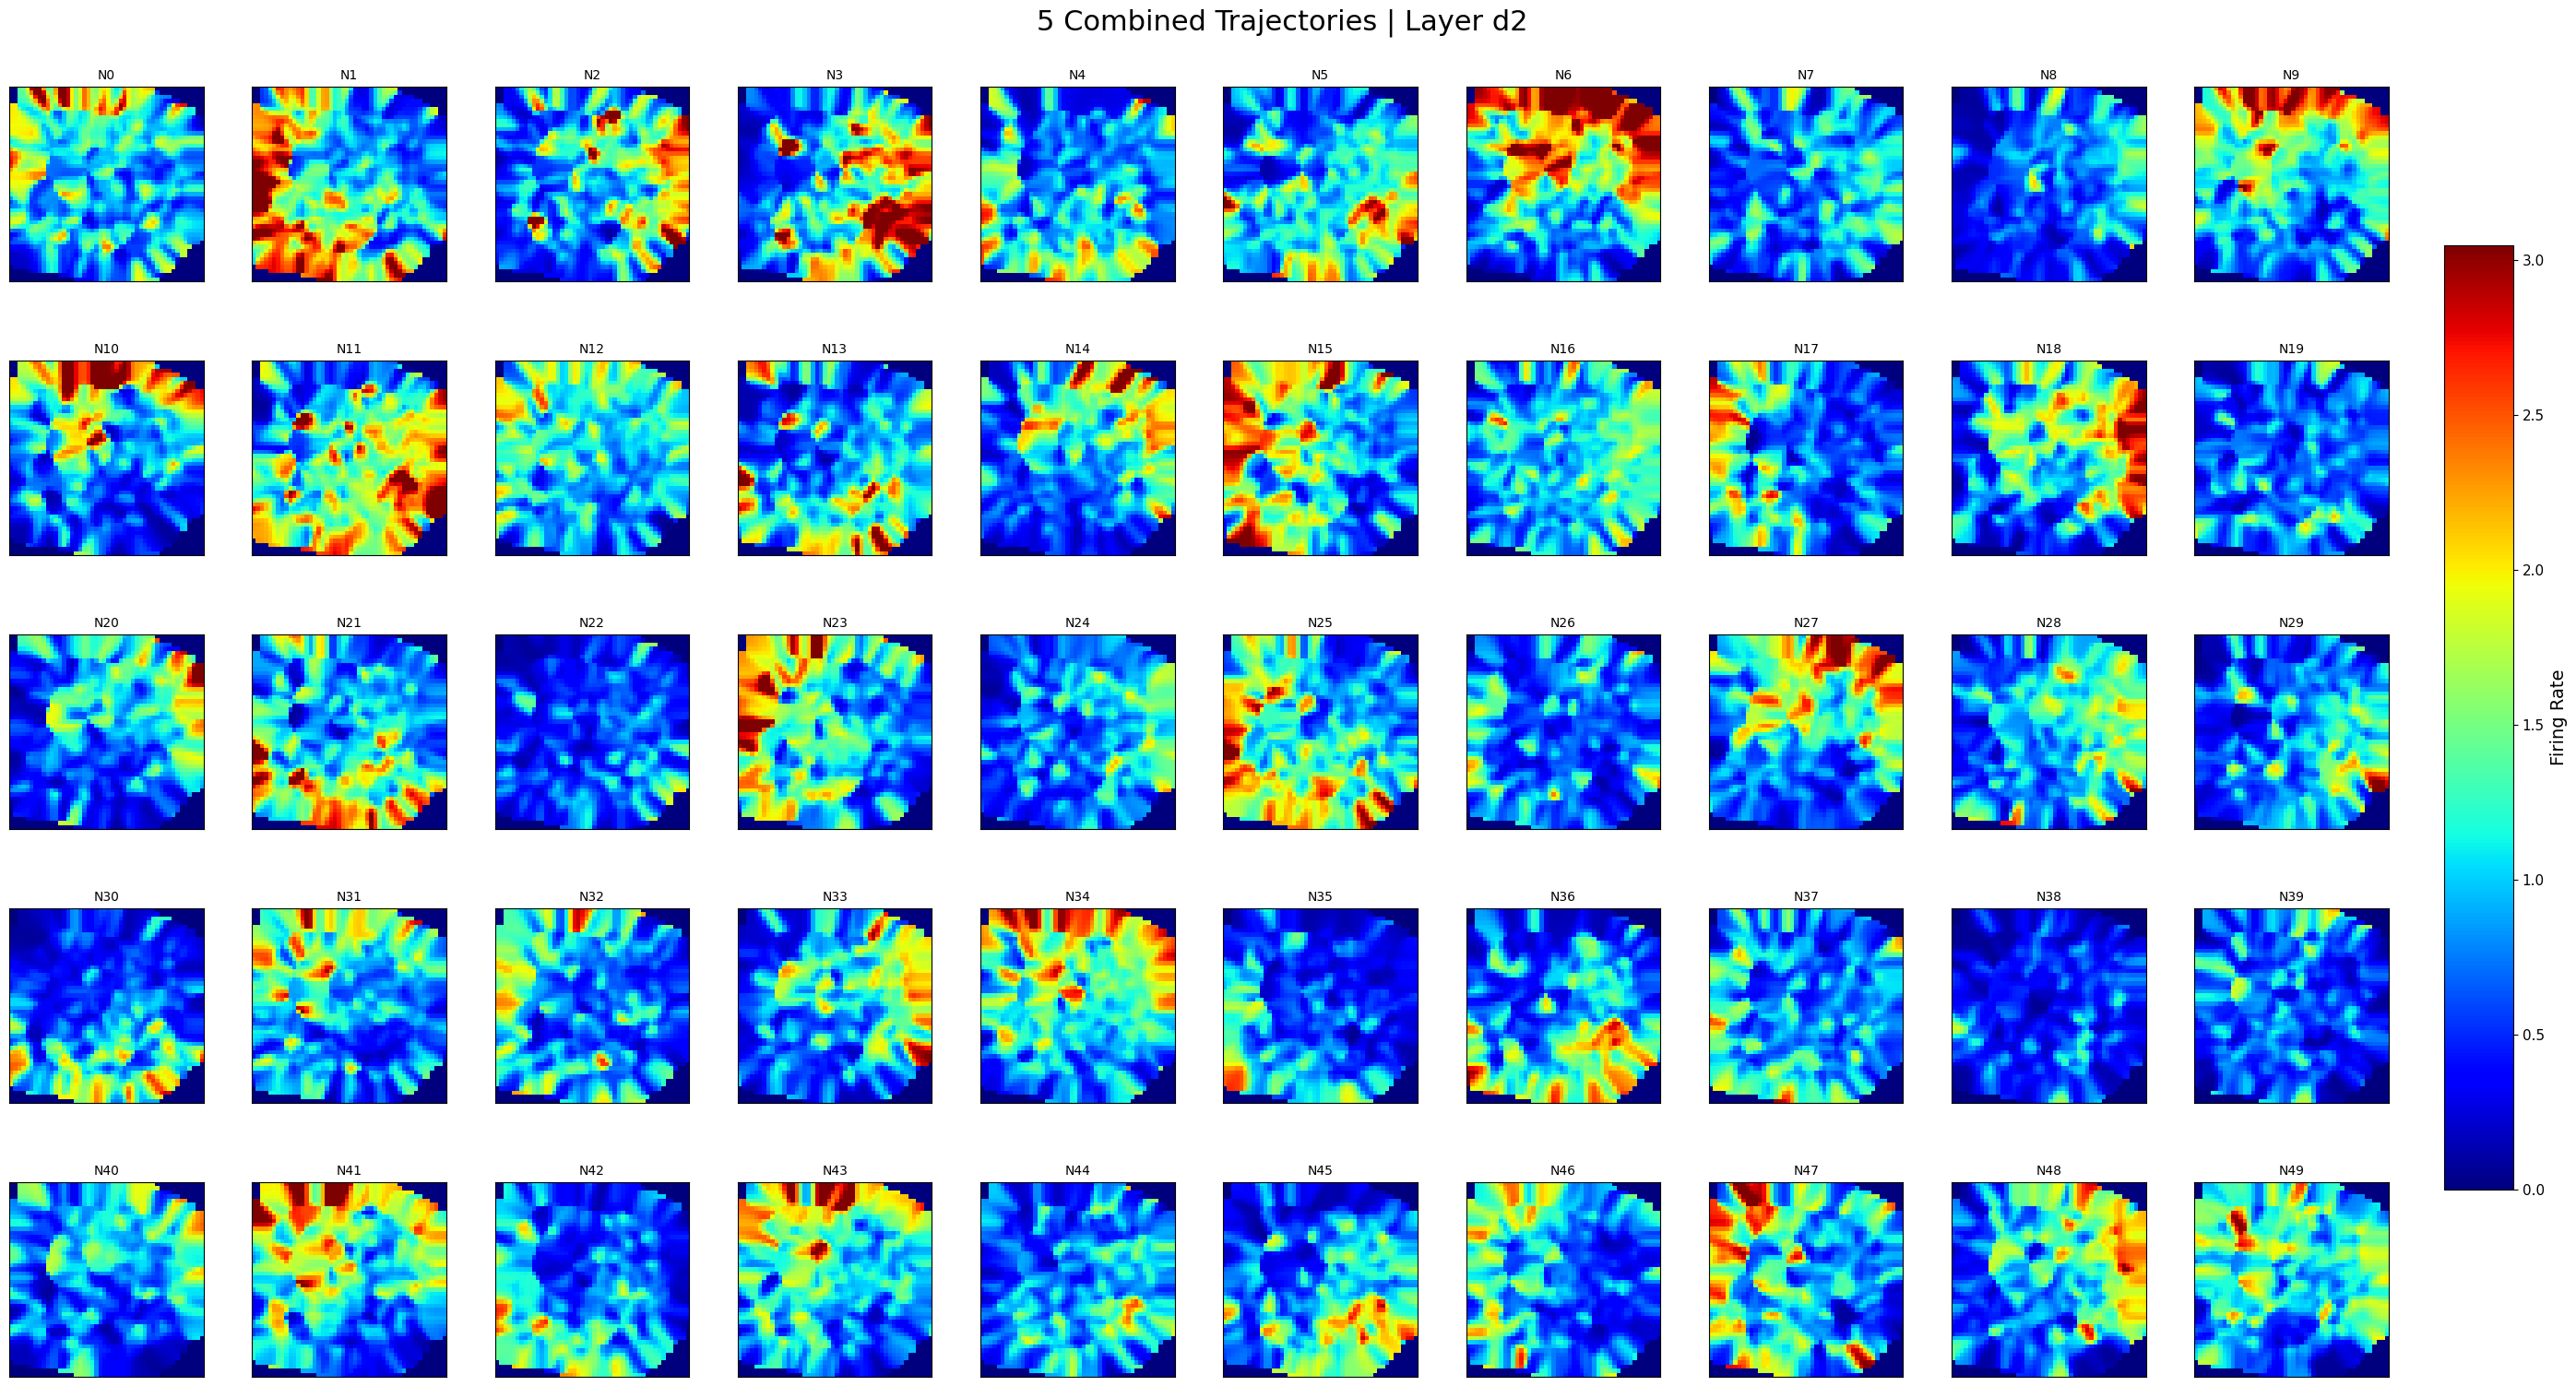

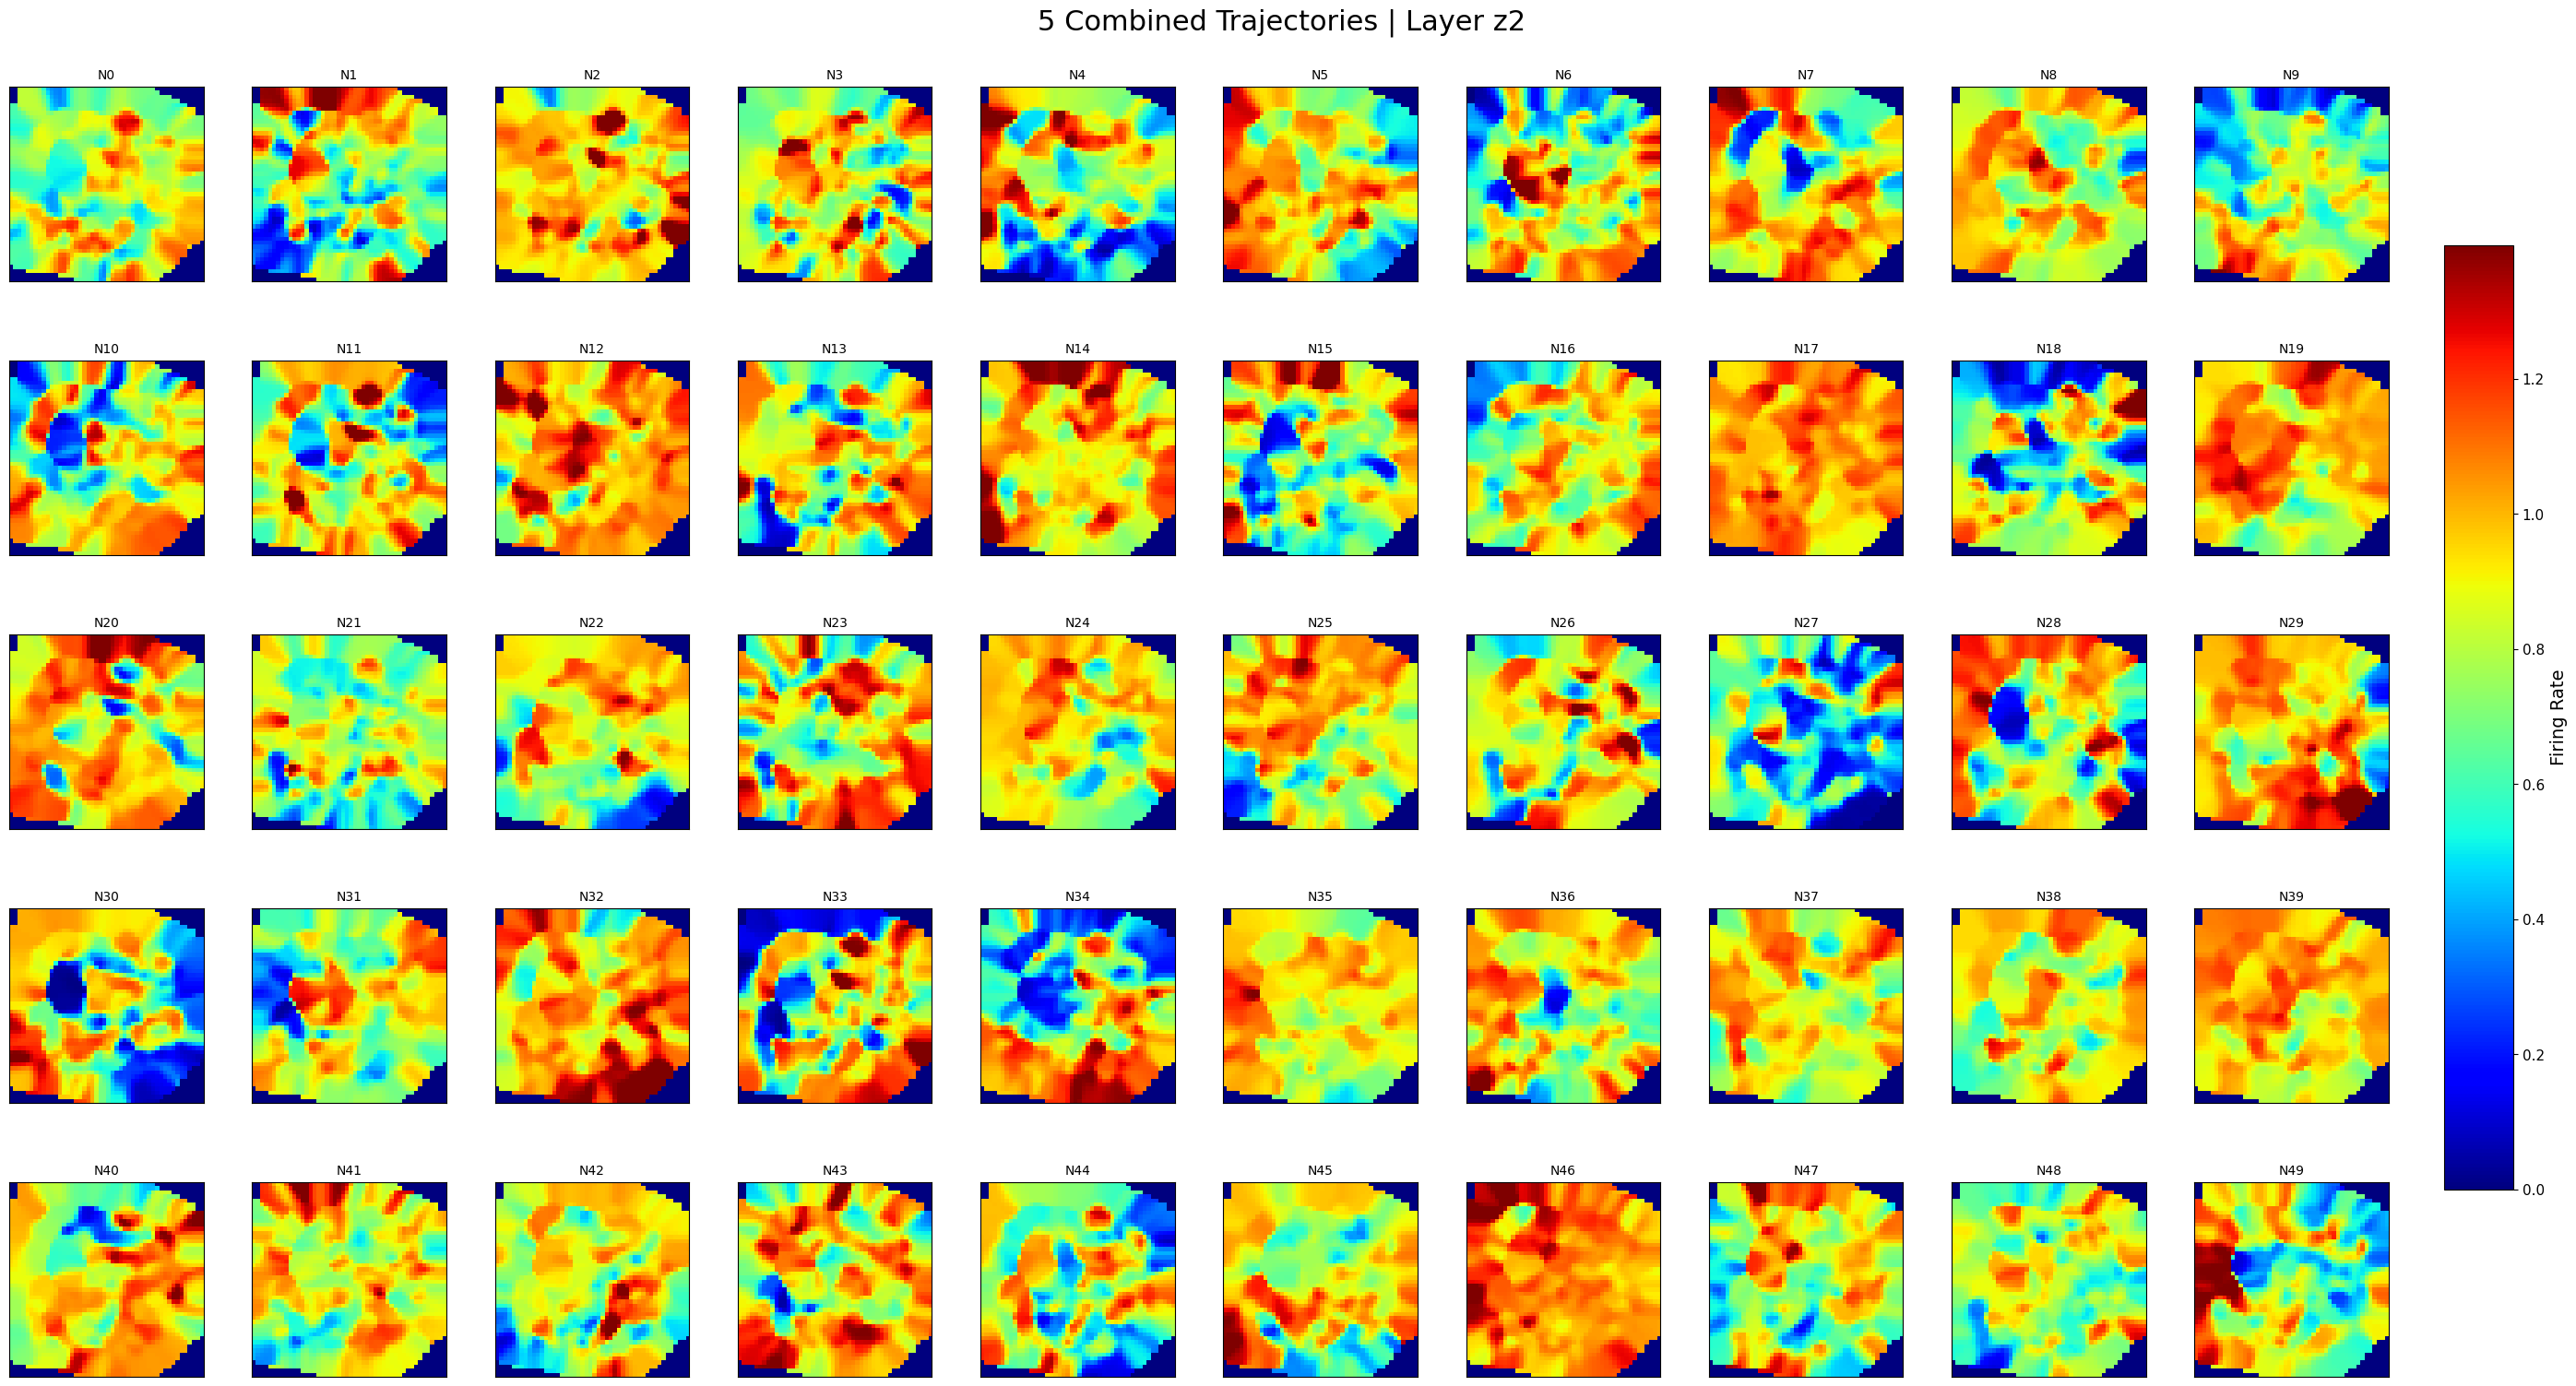

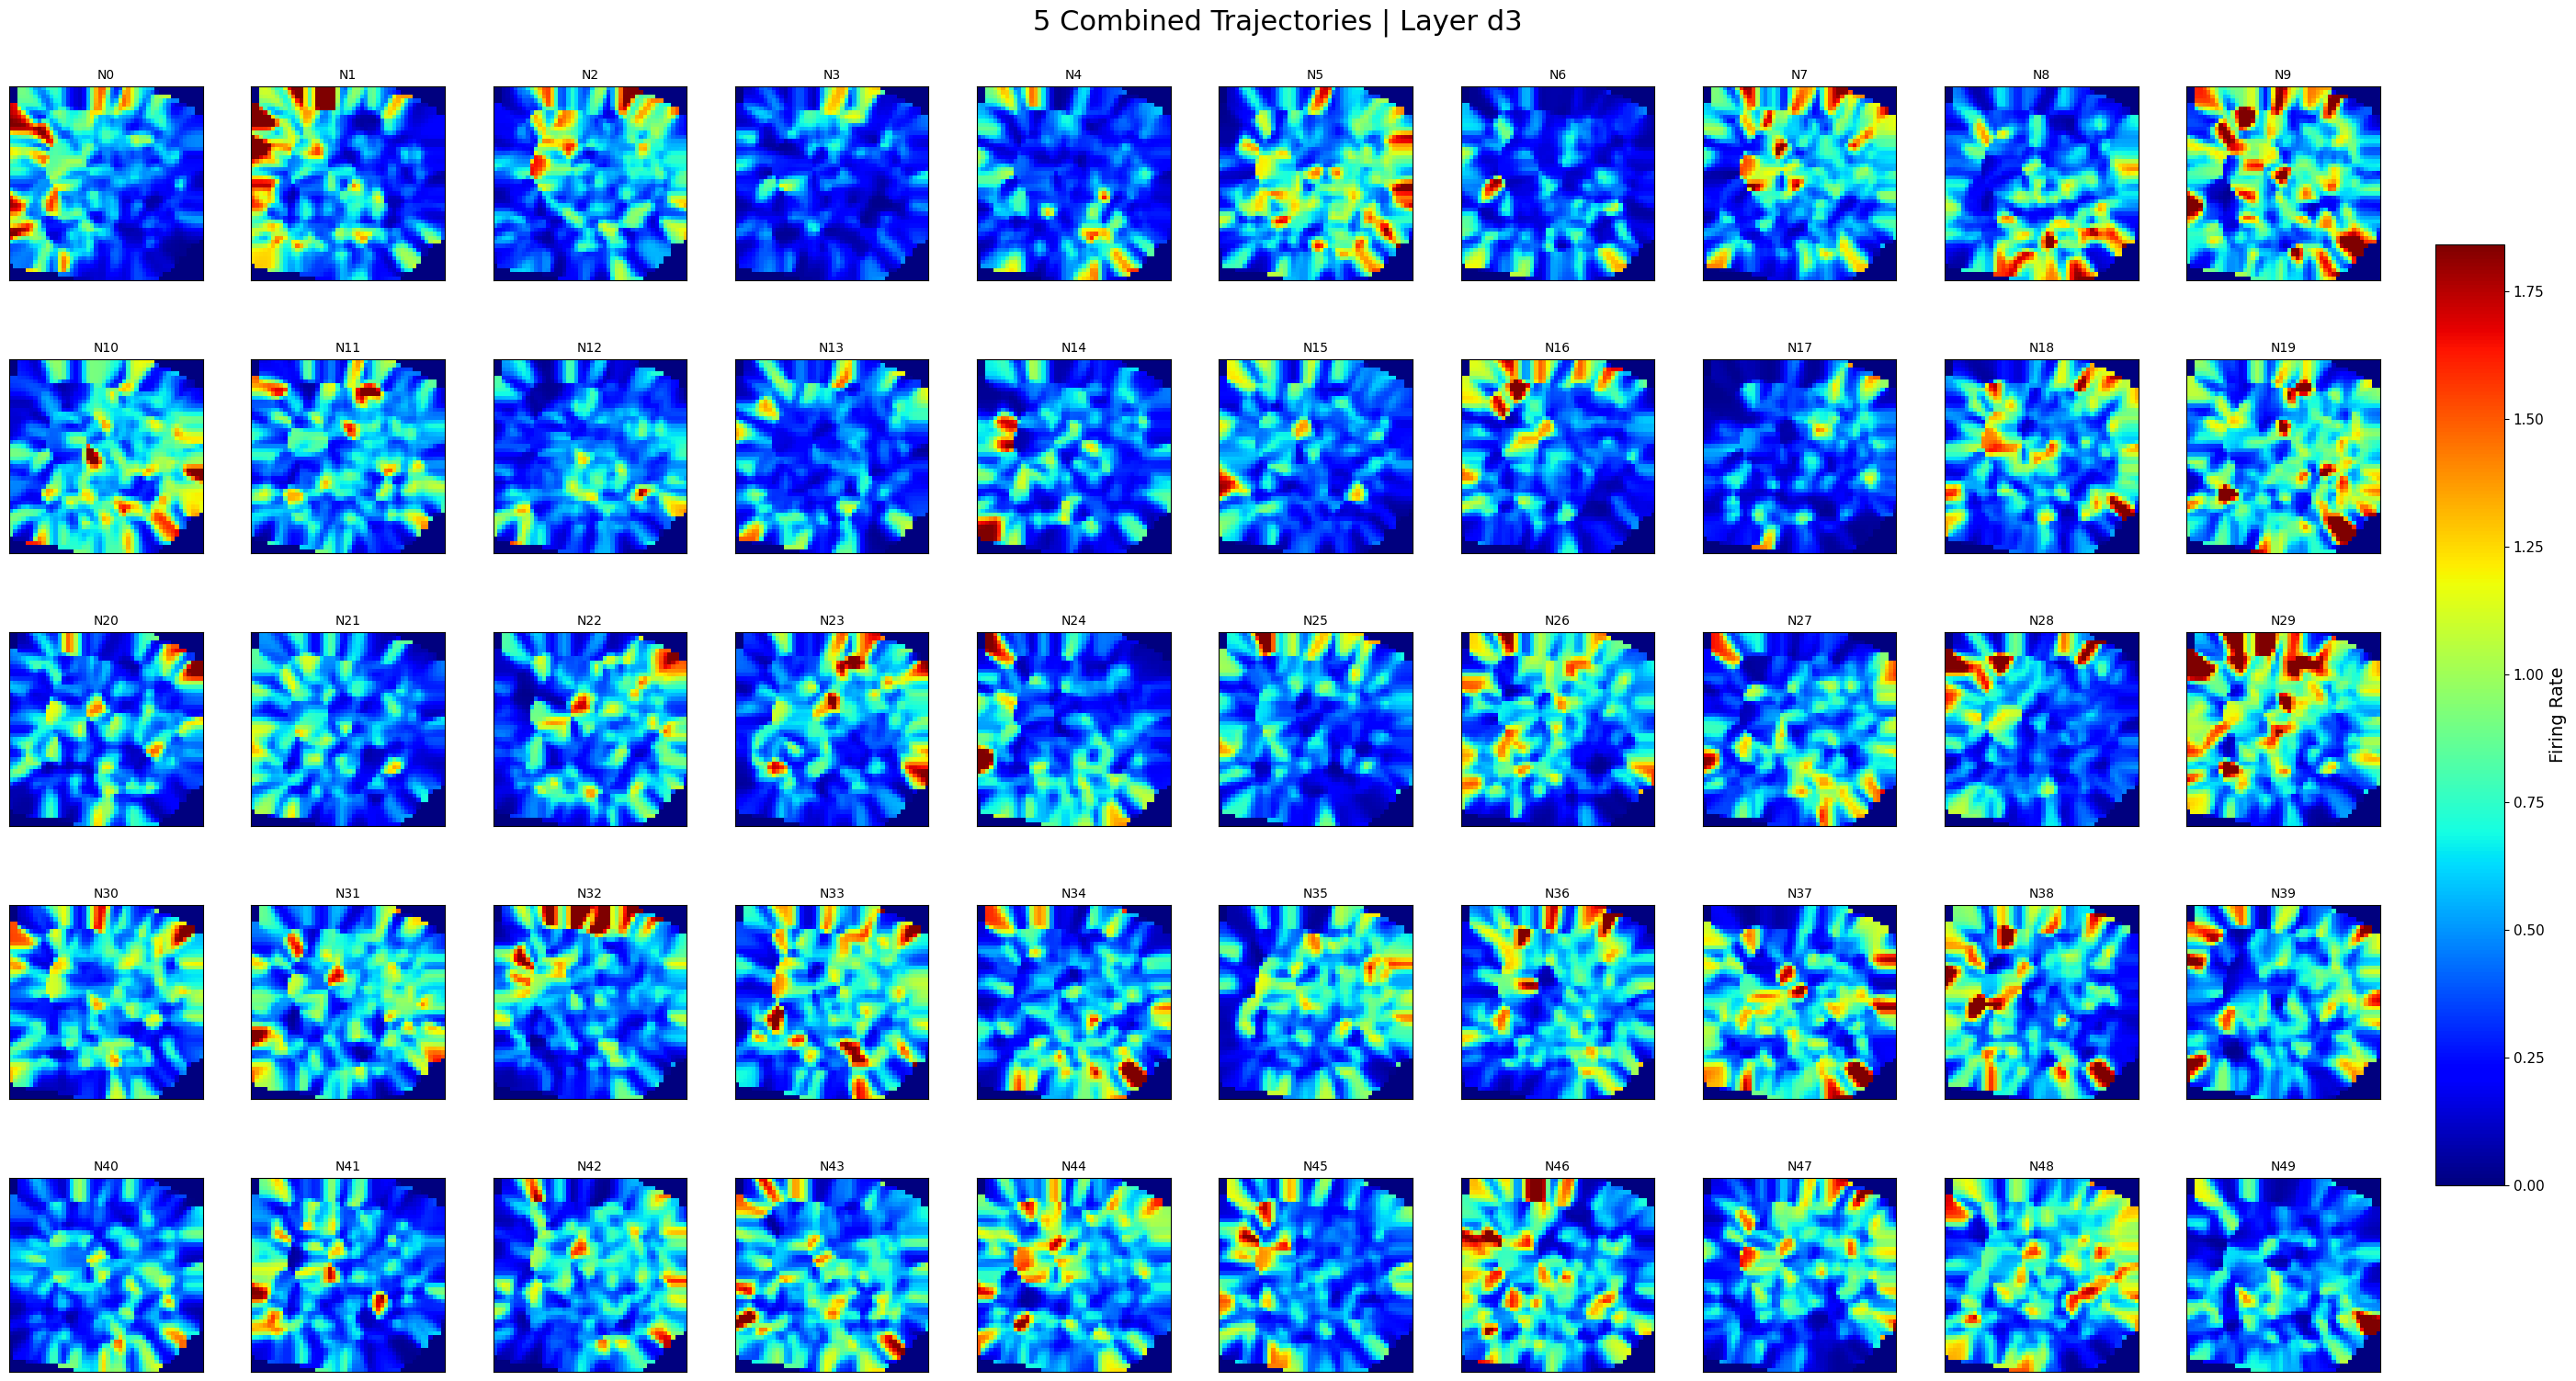

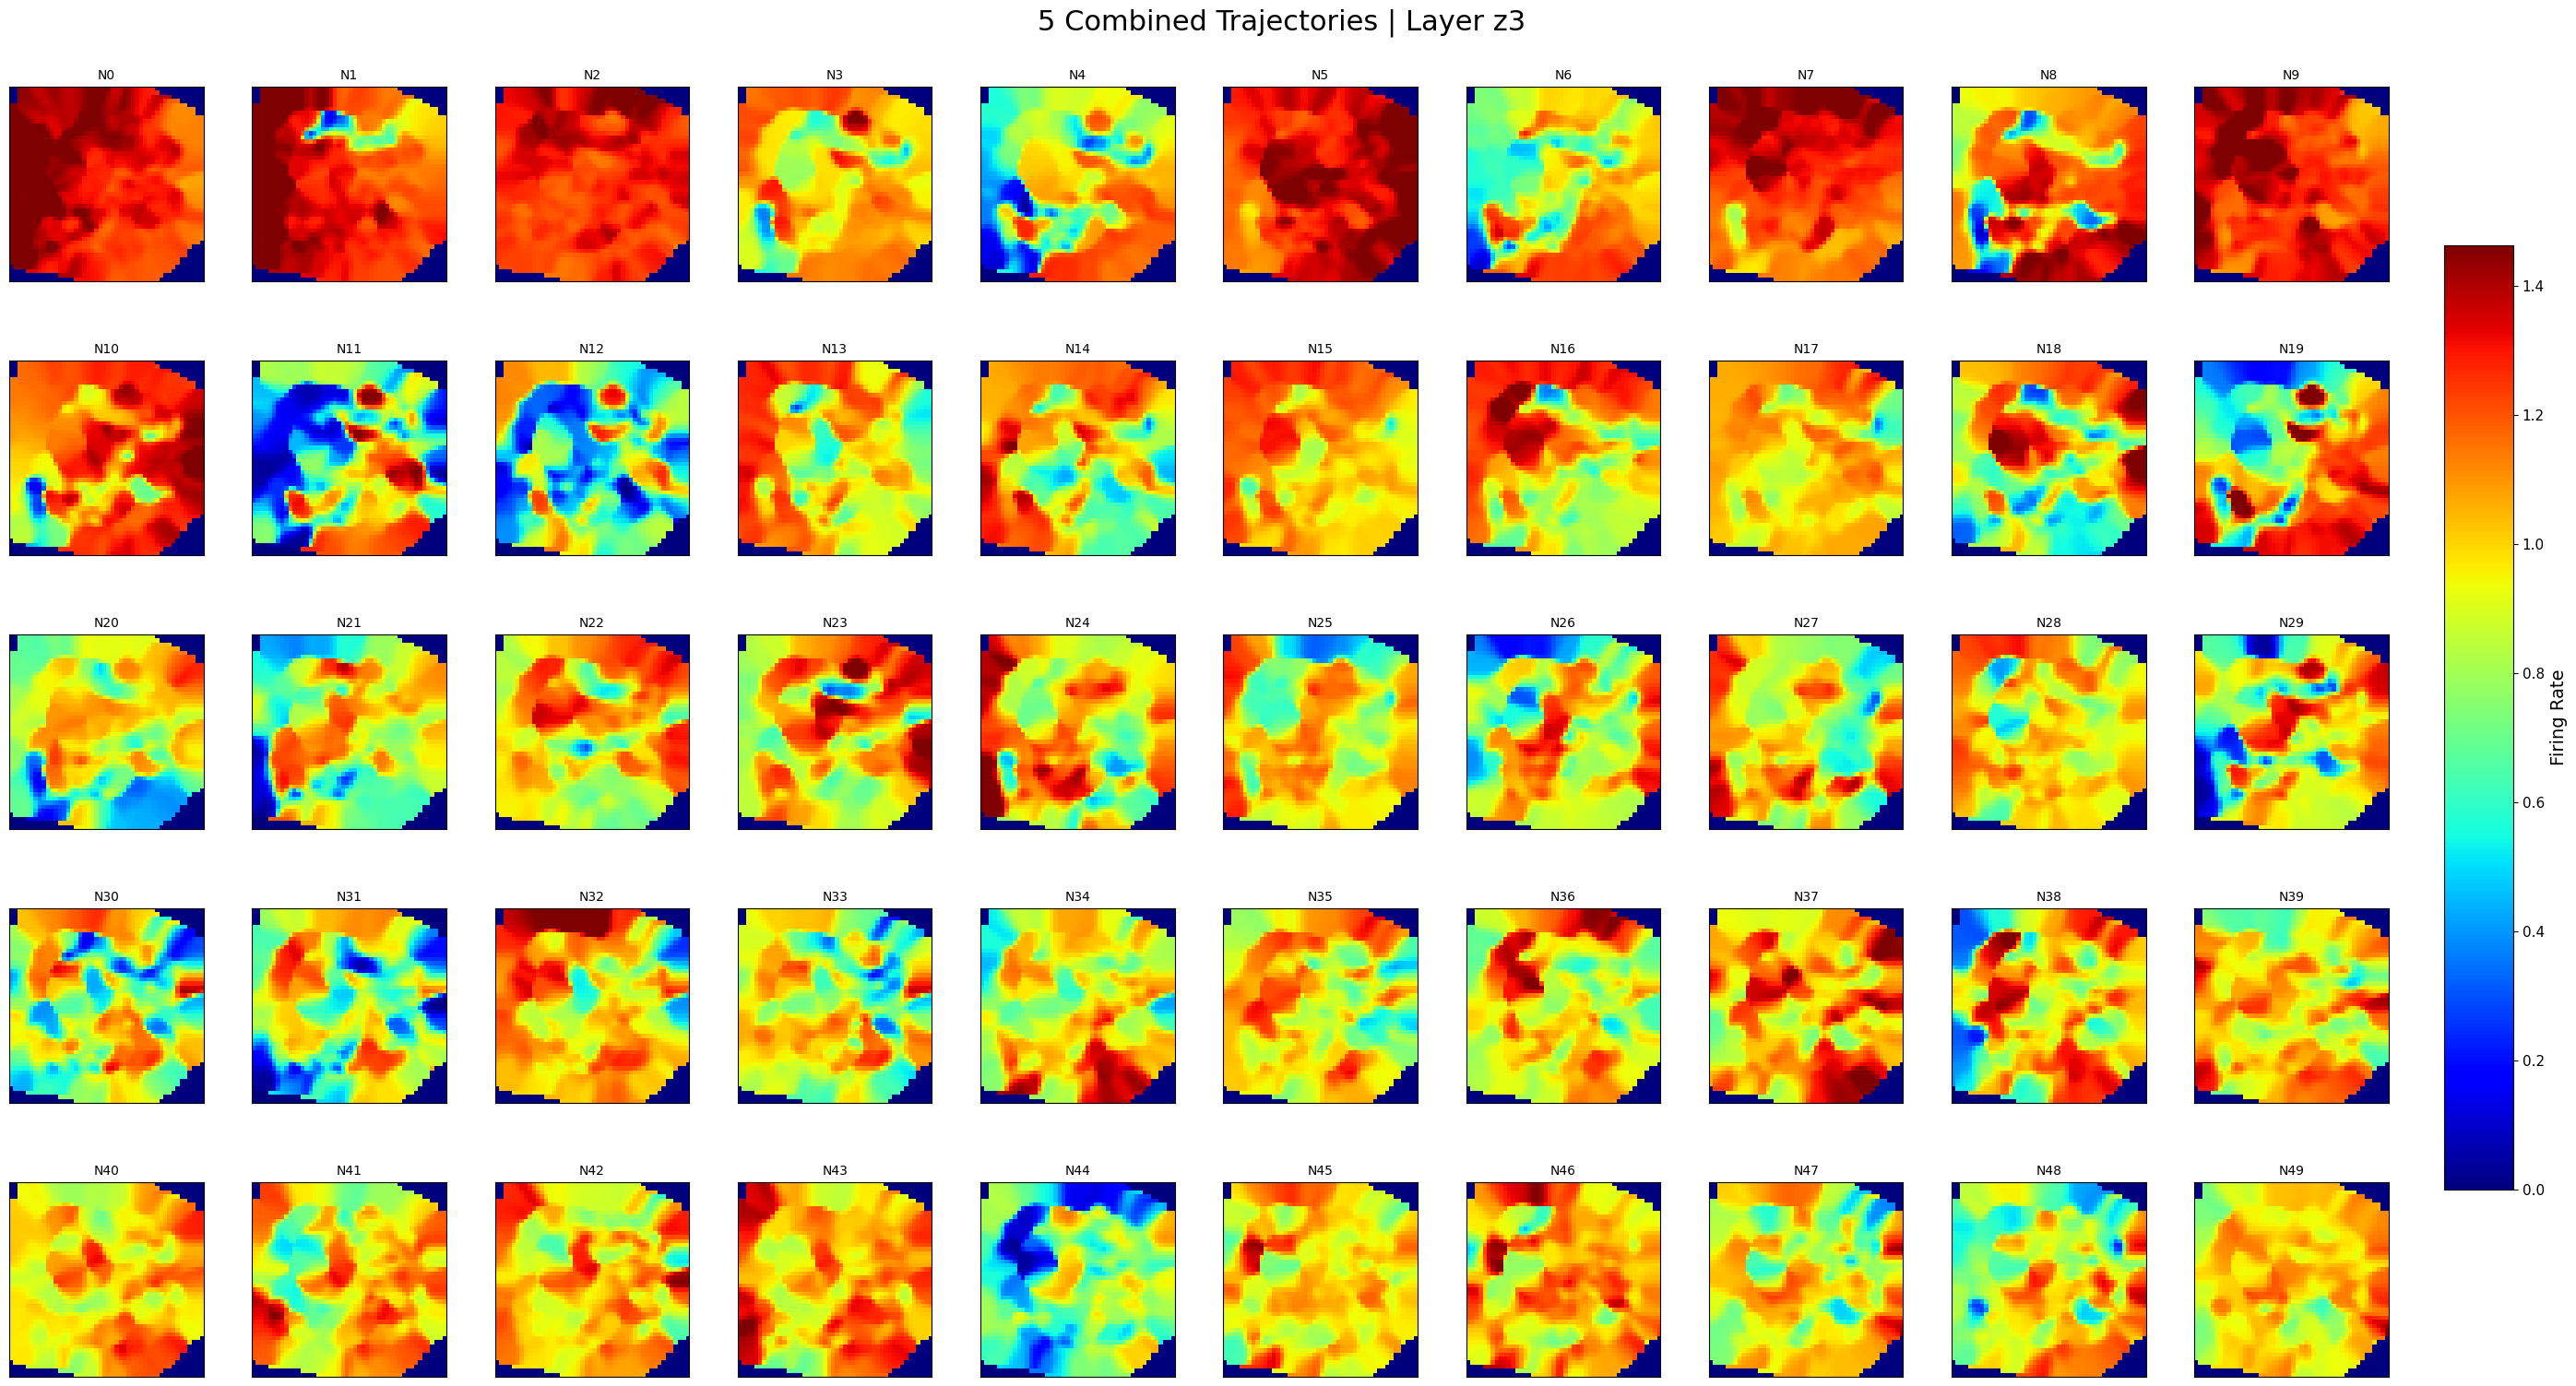

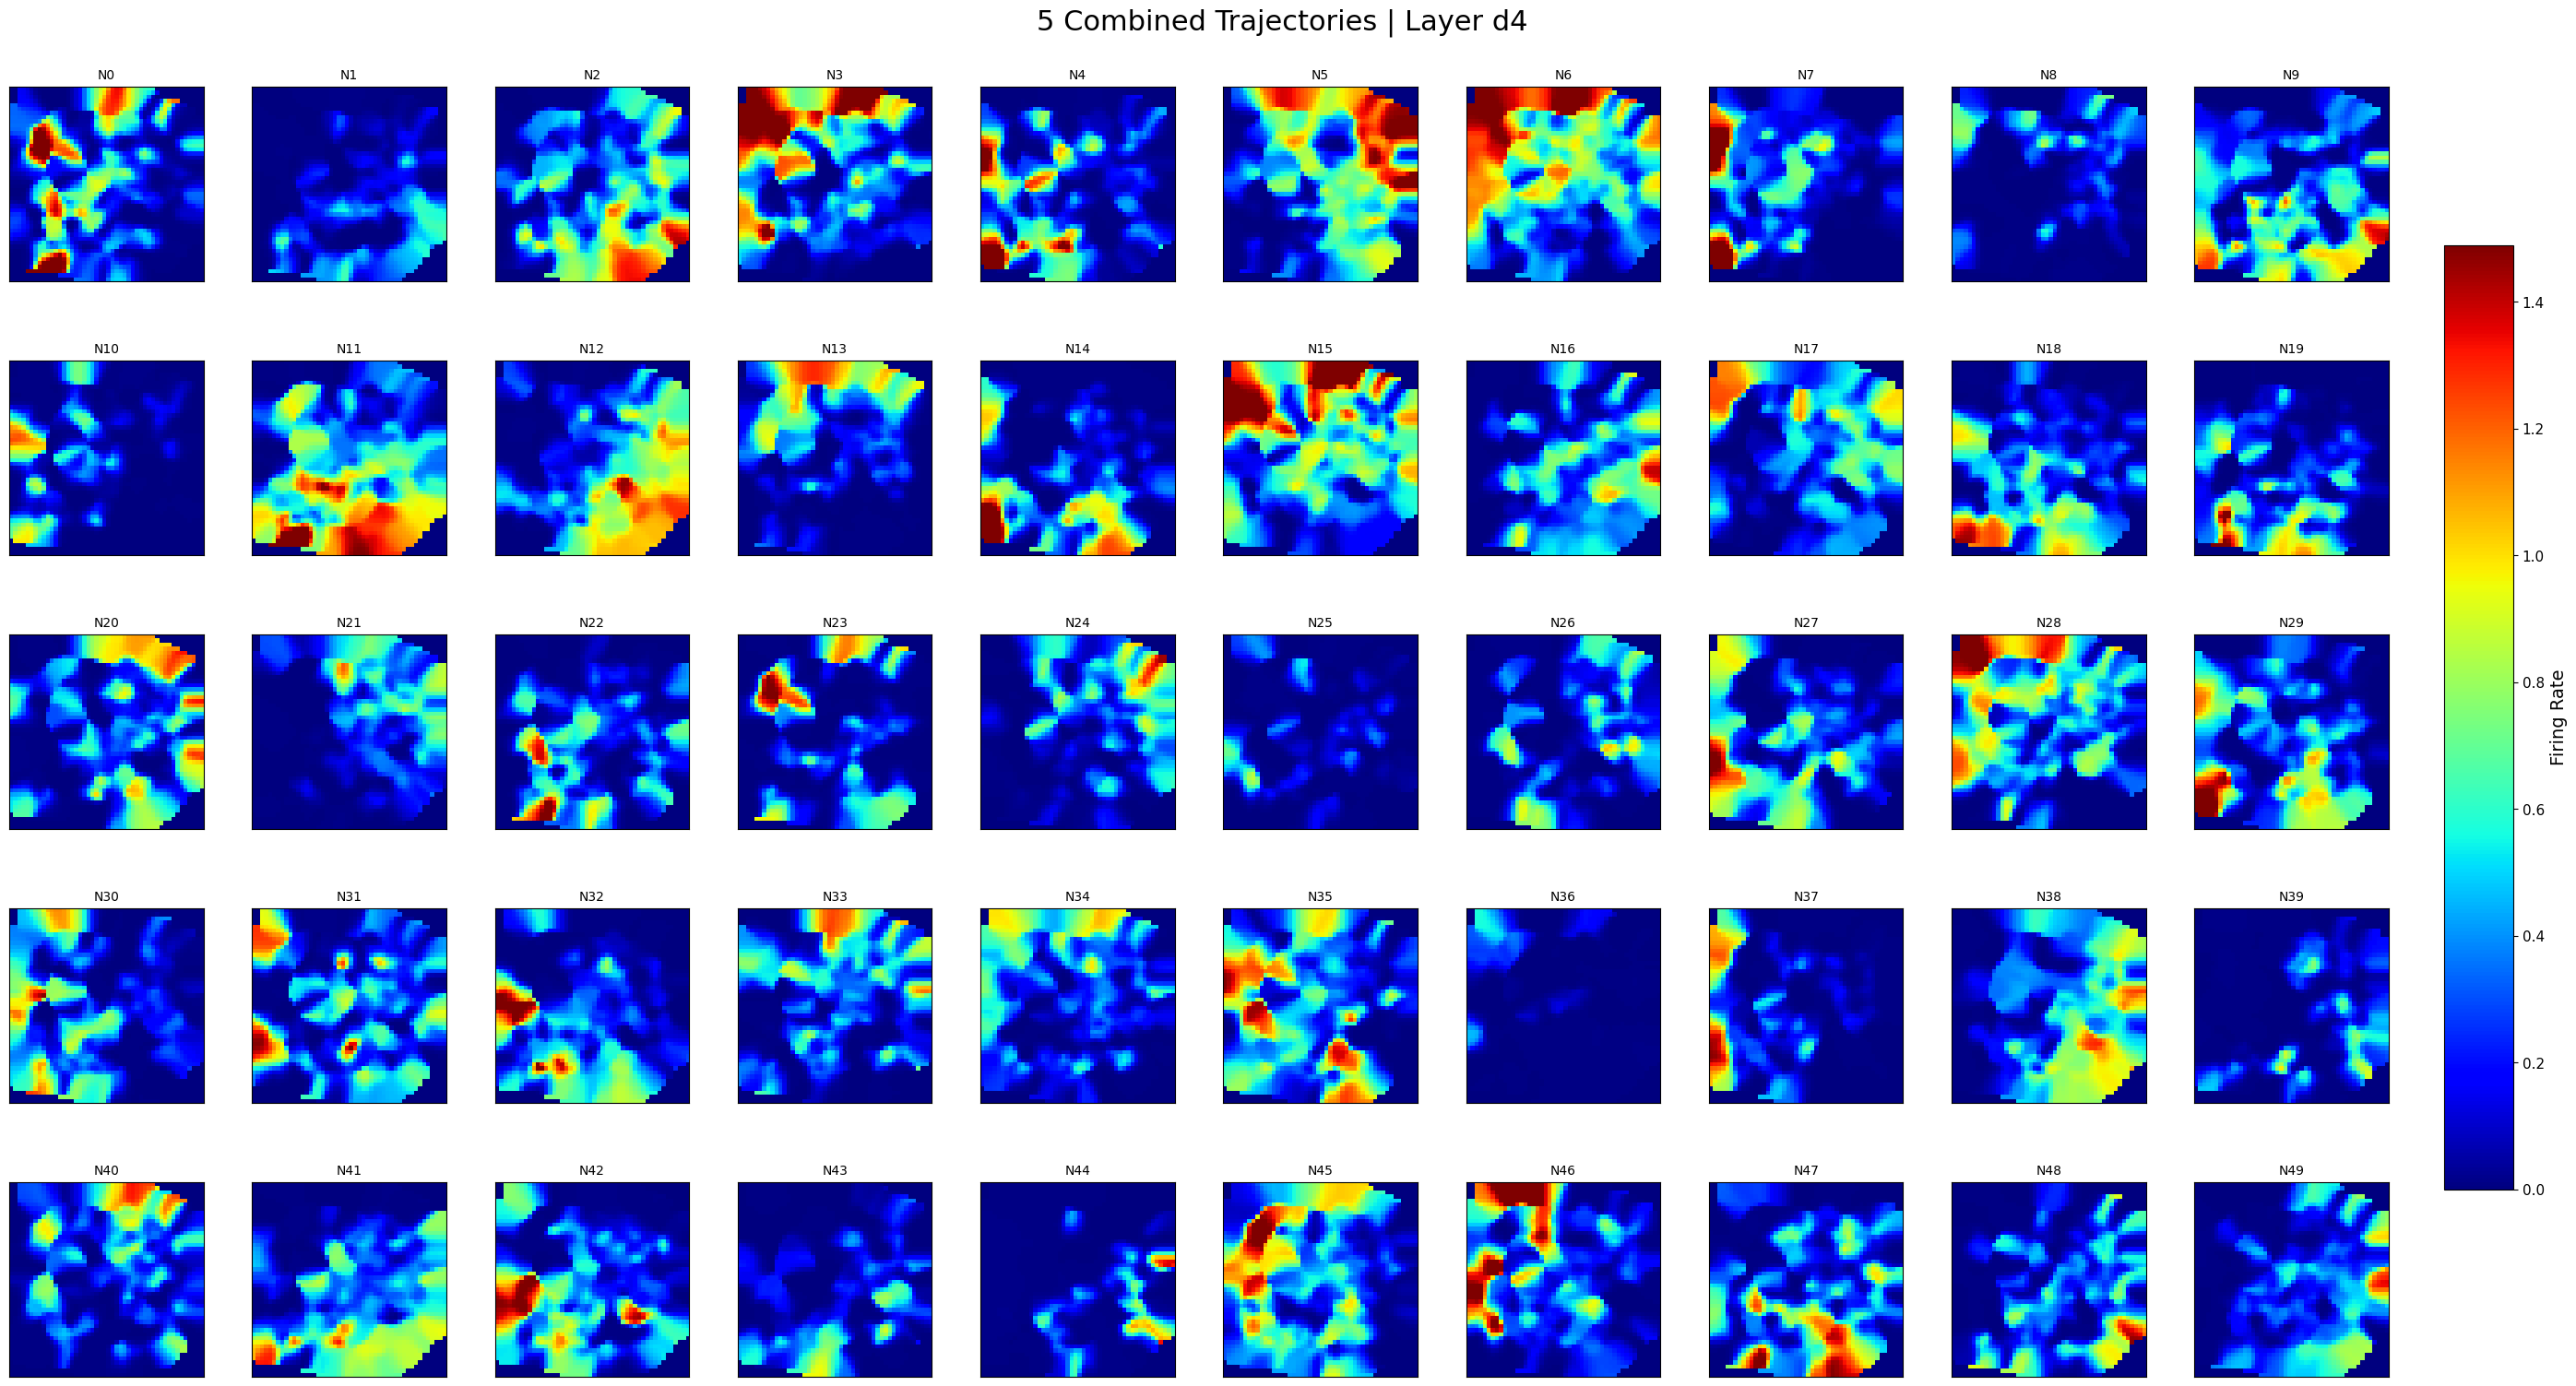

In [28]:
###########################################################
# Load data
###########################################################

ground_truth, prediction, positions, activations = get_input_data(
    pkl_path,
    layer_name=layer_name,
)

###########################################################
# Randomly choose trajectories to combine
###########################################################

RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)

traj_indices = rng.choice(
    len(positions),
    size=N_COMBINED_TRAJ,
    replace=False,
)

###########################################################
# Plot combined trajectories
###########################################################

fig, ax = plt.subplots(figsize=(8, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(traj_indices)))

for i, traj in enumerate(traj_indices):

    color = colors[i]

    # Plot predicted trajectory
    ax.plot(
        prediction[traj, :, 0],
        prediction[traj, :, 1],
        color=color,
        lw=2,
        label=f"Trajectory {traj}",
    )

    # Start point
    ax.scatter(
        prediction[traj, 0, 0],
        prediction[traj, 0, 1],
        color=color,
        marker="o",
        s=80,
        edgecolor="black",
        zorder=5,
    )

    # End point
    ax.scatter(
        prediction[traj, -1, 0],
        prediction[traj, -1, 1],
        color=color,
        marker="X",
        s=100,
        edgecolor="black",
        zorder=5,
    )

ax.set_xlim(BOUNDS)
ax.set_ylim(BOUNDS)

ax.set_aspect("equal")

ax.set_xlabel("x")
ax.set_ylabel("y")

ax.grid(alpha=0.3)

ax.set_title(
    f"{N_COMBINED_TRAJ} Combined Trajectories"
)

ax.legend(
    fontsize=8,
    ncol=2,
)

plt.show()

###########################################################
# Plot firing-rate maps
###########################################################

ground_truth, prediction, positions, activations = get_input_data(
    pkl_path,
    layer_name=layer_name,
)

plot_combined_trajectory(
    ground_truth,
    prediction,
    traj_indices,
)

plot_all_layers_for_trajectory(
    pkl_path,
    traj_indices,
)

In [29]:
MIN_OCCUPANCY = 0.5   # tune this to whatever threshold worked for your border fix

metrics_df = compute_metrics_all_layers(
    pkl_path, traj_indices,
    bins=N_BINS, bounds=BOUNDS, sigma=SIGMA, eps=EPS,
    min_occupancy=MIN_OCCUPANCY,
)

# Top spatially-informative neurons, layer d4 only
metrics_df[metrics_df["layer"] == "d4"].sort_values("spatial_info", ascending=False).head(10)

# Sparsity distribution per layer, quick sanity check
metrics_df.groupby("layer")[["spatial_info", "sparsity"]].describe()

spatial_info                                                    \
             count      mean       std       min       25%       50%   
layer                                                                  
d1           100.0  0.382415  0.207149  0.042648  0.240930  0.343623   
d2           100.0  0.146663  0.046356  0.063582  0.114519  0.140698   
d3           100.0  0.140182  0.030866  0.076664  0.117159  0.138806   
d4           100.0  0.727045  0.374725  0.219533  0.448421  0.625200   
z1           100.0  0.063208  0.055140  0.004060  0.022810  0.047292   
z2           100.0  0.049174  0.035748  0.005355  0.022802  0.039545   
z3           100.0  0.025923  0.028110  0.002338  0.009175  0.015358   

                          sparsity                                          \
            75%       max    count      mean       std       min       25%   
layer                                                                        
d1     0.513482  1.208724    100.0  0.640815  0.150286  0.253476  0.520337   
d2     0.175499  0.286252    100.0  0.830289  0.046860  0.701160  0.804211   
d3     0.161553  0.252200    100.0  0.832219  0.034350  0.710946  0.809635   
d4     0.881560  2.080939    100.0  0.505933  0.158990  0.112488  0.396888   
z1     0.085093  0.291184    100.0  0.927536  0.058174  0.706884  0.895682   
z2     0.062155  0.185939    100.0  0.942642  0.036958  0.818858  0.928758   
z3     0.031641  0.172152    100.0  0.968553  0.030006  0.828767  0.958572   

                                     
            50%       75%       max  
layer                                
d1     0.647625  0.749496  0.942495  
d2     0.835009  0.863091  0.919649  
d3     0.837128  0.856017  0.903460  
d4     0.531597  0.627733  0.794946  
z1     0.945494  0.972025  0.994663  
z2     0.950523  0.969760  0.992610  
z3     0.979853  0.987617  0.996738

In [30]:
place_cells = metrics_df[
    (metrics_df["spatial_info"] > SI_THRESHOLD) &
    (metrics_df["sparsity"] < SPARSITY_THRESHOLD)
]

In [31]:
print(place_cells)

    layer  neuron  spatial_info  sparsity
26     d1      26      1.208724  0.253476
610    d4      10      1.415200  0.247690
636    d4      36      1.818168  0.112488
637    d4      37      1.175430  0.278132
644    d4      44      1.306261  0.289497
650    d4      50      1.306394  0.253556
656    d4      56      1.327267  0.284750
661    d4      61      1.334068  0.277229
662    d4      62      1.149697  0.295036
664    d4      64      1.428115  0.251816
671    d4      71      1.509577  0.225159
676    d4      76      1.221502  0.282952
677    d4      77      1.500946  0.214500
678    d4      78      1.356114  0.225738
679    d4      79      2.080939  0.123407
687    d4      87      1.255366  0.287122


In [32]:
place_cells.groupby("layer").size()

layer
d1     1
d4    15
dtype: int64

In [33]:
layer = "d4"

# Load the layer
_, _, positions, activations = get_input_data(
    pkl_path,
    layer_name=layer,
)

# Compute firing maps
firing_maps, occ_map = compute_all_neuron_maps(
    positions,
    activations,
    traj_indices,
    bins=N_BINS,
    bounds=BOUNDS,
    sigma=SIGMA,
    eps=EPS,
    min_occupancy=MIN_OCCUPANCY,
)

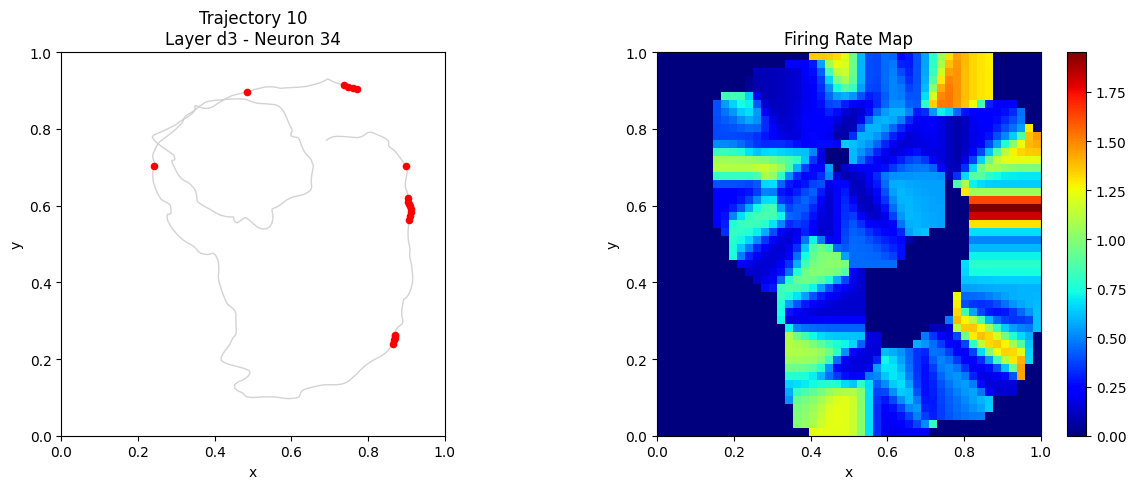

In [45]:
# ============================================================================
# Trajectory map + firing rate map (Trajectory 10, d3 neuron 34)
# ============================================================================

LAYER = "d3"
TRAJ = 10
NEURON = 34

# Load data
_, _, positions, activations = get_input_data(
    pkl_path,
    layer_name=LAYER,
)

# Remove first 50 timesteps
positions = positions[:, 50:, :]
activations = activations[:, 50:, :]

# Compute firing map for ONLY trajectory 10
firing_maps, occupancy = compute_all_neuron_maps(
    positions,
    activations,
    traj_indices=[TRAJ],
)

# ------------------------------------------------------------------
# Extract this trajectory
# ------------------------------------------------------------------

traj_pos = positions[TRAJ]

# Convert complex activations to magnitude
traj_act = np.abs(activations[TRAJ, :, NEURON])

# Top 5% strongest activations
threshold = np.percentile(traj_act, 95)
active = traj_act >= threshold

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---------------- Trajectory ----------------
ax = axes[0]

ax.plot(
    traj_pos[:, 0],
    traj_pos[:, 1],
    color="lightgray",
    linewidth=1,
    zorder=1,
)

ax.scatter(
    traj_pos[active, 0],
    traj_pos[active, 1],
    c="red",
    s=20,
    zorder=2,
)

ax.set_title(f"Trajectory {TRAJ}\nLayer {LAYER} - Neuron {NEURON}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")

# ---------------- Firing Rate Map ----------------
ax = axes[1]

im = ax.imshow(
    firing_maps[NEURON].T,
    origin="lower",
    extent=[0, 1, 0, 1],
    cmap="jet",
)

ax.set_title("Firing Rate Map")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")

plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()